In [ ]:
# All relevant imports for the notebook
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import shapely
import numpy as np
import re
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import folium
import ipywidgets as widgets
from IPython.display import display, clear_output

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Members:**

---


1. Chia Xin Yue
2. Lim Zi Xin
3. Shaun Lim Yu Xin (Lin Yuxin)


**Link to our datasets:**

https://drive.google.com/drive/folders/1HyfeQBr8H8ZPd83K3To2TcXEBzb1rBb5?usp=sharing

# Question: "How can we identify planning areas in Singapore that are underserved by public library resources relative to their resident student population?"

## Hypothesis







> *Clearly state the data science hypothesis / the analytical goal you pursue in your project. From your description, it should be clear which question you address, what type of analysis is needed, and what quality metric is targeted.*

Public libraries in Singapore have transitioned from book repositories into essential spaces for students to learn and collaborate. A question that we have is whether public library resources, when weighted against Service Capacity, are distributed equitably across planning areas in Singapore, relative to their Resident Student Population (defined as residents enrolled in educational institutions). We hypothesize that there is a measurable disparity in the availability of public libraries across planning areas in Singapore. In particular, planning areas experiencing higher student population growth may be more susceptible to inadequate public library resources in the future. In this context, we will explore the possible correlation between student population trajectories and current weighted capacities. This descriptive analysis may support National Library Board (NLB) for future library development and resource allocation to underserved areas. We emphasize that we do not take into account school facilities and equivalents, where the former is accessible to students only and are often limited to school hours, and that we are discussing this through a nationwide lens.

## Data source identification and exploration (Prepare)


> Make a brief requirements analysis for the data and data sources that you require to reach your goal.

**Requirement analysis:** To tackle this problem, we need to have geographical data about library locations across planning areas in Singapore. In addition, we also need to have data of the resident student population so as to gauge the number of potential student library users per planning area. We also recognise that library capacity may vary by branch. Therefore, it would be advantageous in having data about exact library capacity so as to quantify the true service volume available to students in each library.







> *List the sources you will report on for Deliverable 1 and link them to where you found them. In selecting which datasets you want to report on for exploration, take note of the following: (1) The subsequent data preparation and analysis should rely on at least 3 datasets; (2) the discussion concerning exploration needs to feature arguments for why datasets were selected and why others were not. No generated data should be used.*



### List of considered sources
> In the following section, we outline the sources we have considered to help tackle the problem statement.

**Geographical Data**
- Source 1 - Libraries: https://data.gov.sg/datasets/d_27b8dae65d9ca1539e14d09578b17cbf/view
- Source 2 - Master Plan 2019 Planning Area Boundary (No Sea): https://data.gov.sg/datasets/d_4765db0e87b9c86336792efe8a1f7a66/view
- Source 3 - Master Plan 2008 Subzone Boundary (No Sea): https://data.gov.sg/collections/1684/view
- Source 4 - Master Plan 2014 Subzone Boundary (No Sea): https://data.gov.sg/collections/1707/view
   
**Resident Student Population Data**
- Source 5 - Resident Students Aged 5 Years and Over by Planning Area of Residence and Usual Mode of Transport to School (Census of Population 2020): https://data.gov.sg/datasets/d_9eaccc6cc0f257cfd74d5c1ceb0fb663/view

- Source 6 - Resident Students Aged 5 Years and Over by Planning Area of Residence and Level of Education Attending (Census of Population 2020): https://data.gov.sg/datasets/d_b19c5bc4f6916b5481f6531918440fe6/view
- Source 7 -  Resident Students Aged 5 Years and Over by Planning Area and Level of Education Attending (Census of Population 2010): https://data.gov.sg/datasets/d_7dd573b7e1c4cae2c0c70559037d0e4e/view
- Source 8 - Resident Students Aged 5 Years and Over by Planning Area and Level of Education Attending (General Household Survey 2015): https://data.gov.sg/datasets/d_d876df5461b5fa36443b32fa529bed56/view
- Source 9 - Resident Students Aged 5 Years and Over by DGP Zone and Level of Education Attending (Census of Population 2000): https://data.gov.sg/datasets/d_77fe63cfafc6903c271ab0cbc6ee205e/view

**Supplementary Library Data**
- Source 10 - Supplementary Library Capacity Data






### DS1: Libraries

**Description**: The dataset downloaded from data.gov.sg, contains a map, with location data of the various public libraries in Singapore. It provides spatial coordinates(Points) and detailed attributes such as library names and addresses, which are essential for our anaylsis. It is at an appropriate level of granularity to be used with our data on the planning areas in Singapore. The following code imports the GeoJSON into a GeoData and displays the first few rows to verify data structure.




In [ ]:
# Loading file
df_libraries = gpd.read_file('/content/drive/MyDrive/SC3021_Datasets/Libraries.geojson')
print(df_libraries.head())


    Name                                        Description  \
0  kml_1  <center><table><tr><th colspan='2' align='cent...   
1  kml_2  <center><table><tr><th colspan='2' align='cent...   
2  kml_3  <center><table><tr><th colspan='2' align='cent...   
3  kml_4  <center><table><tr><th colspan='2' align='cent...   
4  kml_5  <center><table><tr><th colspan='2' align='cent...   

                        geometry  
0  POINT Z (103.87226 1.35073 0)  
1  POINT Z (103.83967 1.30041 0)  
2  POINT Z (103.88584 1.31744 0)  
3  POINT Z (103.70451 1.34064 0)  
4   POINT Z (103.74929 1.3495 0)  


From this sample of data, we discovered that important attributes such as library name, address and postal code are embedded in the Description column. For more meaningful analysis, we need to extract the attributes from the Description column using Pattern extraction into new columns. Other attributes that are not relevant to our project (Photourl,Addressfloornumber) are also parsed out in our processing.

In [ ]:
# We first define a function to use Regular Expressions to find attributes
def extract_library_info(string, info):
  """
  Extract library information from the 'Description' column.

  Arg:
  ----
    string(str): Raw rtext from 'Description' column of the GeoJSON
    info(str): Specific attribute key to extract (e.g 'POSTAL_CODE')

  Returns:
  ----
    str or None: Extracted value or None if not found
  """
  # Pattern: look for <th> tag, skip whitespace
  pattern = rf'<th>{info}</th>\s*<td>(.*?)</td>'
  pattern_match = re.search(pattern, string)

  if pattern_match: return pattern_match.group(1)
  else: return None

In [ ]:
# Create cleaned columns
df_libraries['Library_Name'] = df_libraries['Description'].apply(lambda x: extract_library_info(x, 'NAME'))
df_libraries['Street_Address'] = df_libraries['Description'].apply(lambda x: extract_library_info(x, 'ADDRESSSTREETNAME'))
df_libraries['Postal_Code'] = df_libraries['Description'].apply(lambda x: extract_library_info(x, 'ADDRESSPOSTALCODE'))

df_newlibraries = df_libraries[['Library_Name', 'Street_Address', 'Postal_Code', 'geometry']].copy()
print(df_newlibraries.head())

                  Library_Name            Street_Address Postal_Code  \
0     Serangoon Public Library         Serangoon Central      556083   
1              library@orchard              Orchard Road      238858   
2  Geylang East Public Library        Geylang East Ave 1      389777   
3   Jurong West Public Library     Jurong West Central 3      648346   
4   Bukit Batok Public Library  Bukit Batok Central Link      658713   

                        geometry  
0  POINT Z (103.87226 1.35073 0)  
1  POINT Z (103.83967 1.30041 0)  
2  POINT Z (103.88584 1.31744 0)  
3  POINT Z (103.70451 1.34064 0)  
4   POINT Z (103.74929 1.3495 0)  


**Exploration Steps of DS1**

As an initial exploration, we perform data profiling to ensure that it has the level of granularity needed for this project.

In [ ]:
# Print out entire table for visual inspection
print(df_newlibraries)




                    Library_Name                Street_Address Postal_Code  \
0       Serangoon Public Library             Serangoon Central      556083   
1                library@orchard                  Orchard Road      238858   
2    Geylang East Public Library            Geylang East Ave 1      389777   
3     Jurong West Public Library         Jurong West Central 3      648346   
4     Bukit Batok Public Library      Bukit Batok Central Link      658713   
5        Sengkang Public Library               Sengkang Square      545078   
6   Marine Parade Public Library            Marine Parade Road      449282   
7       Pasir Ris Public Library        Pasir Ris Central St 3      518457   
8              library@chinatown             North Bridge Road       59413   
9              library@esplanade                Raffles Avenue       39802   
10  Chua Chu Kang Public Library        Choa Chu Kang Avenue 4      689812   
11  Bukit Panjang Public Library                   Jelebu Road  

In [ ]:
# Integrity check: Check null counts
print("Check for null counts.")
null_count = df_newlibraries.isnull().sum()
print("Null counts:\n", null_count)


# Uniqueness Check: Check for duplicate postal codes
print("\nCheck for duplicate postal codes.")
total_count = df_newlibraries['Postal_Code'].count()
print("Total count:", total_count)
distinct_count = df_newlibraries['Postal_Code'].nunique()
print("Number of unique postal codes:", distinct_count)

duplicates = df_newlibraries[df_newlibraries.duplicated(subset=['Postal_Code'], keep=False)]
print("Libraries sharing the same Postal Code: \n",duplicates[['Library_Name', 'Postal_Code']])



# Validation Check: Verify format of postal codes
print("\nCheck for invalid postal codes.")
postal_code_pattern = r'^\d{6}$'
pattern_match = df_newlibraries['Postal_Code'].str.match(postal_code_pattern)
invalid_postal = df_newlibraries[~pattern_match]
print("Invalid postal codes:\n", invalid_postal[['Library_Name','Postal_Code']])

Check for null counts.
Null counts:
 Library_Name      0
Street_Address    0
Postal_Code       0
geometry          0
dtype: int64

Check for duplicate postal codes.
Total count: 27
Number of unique postal codes: 26
Libraries sharing the same Postal Code: 
                  Library_Name Postal_Code
18     Central Public Library      188064
22  National Library Building      188064

Check for invalid postal codes.
Invalid postal codes:
                     Library_Name Postal_Code
8              library@chinatown       59413
9              library@esplanade       39802
19  Harbour Front Public Library       98585


From the above exploration, it can be confirmed that there are no null values, which is good for mapping. Each library listed in the dataset has a corresponding postal code and geometric coordinate. However, two discrepencies noted is that there are duplicated postal code values as well as invalid postal code values.

1. Duplicated values

Upon further research, we discovered that Central Public Library and National Library Building do indeed share the same postal code, rather than it being an error. For our project, we will treat both libraries as one entity to better weigh resource allocation.


2. Invalid values

There are three libraries with invalid postal codes (not 6-digits long). This may be because the leading zero in the postal codes was stripped during data processing. Further data processing is required to re-add the leading zero in these postal codes.

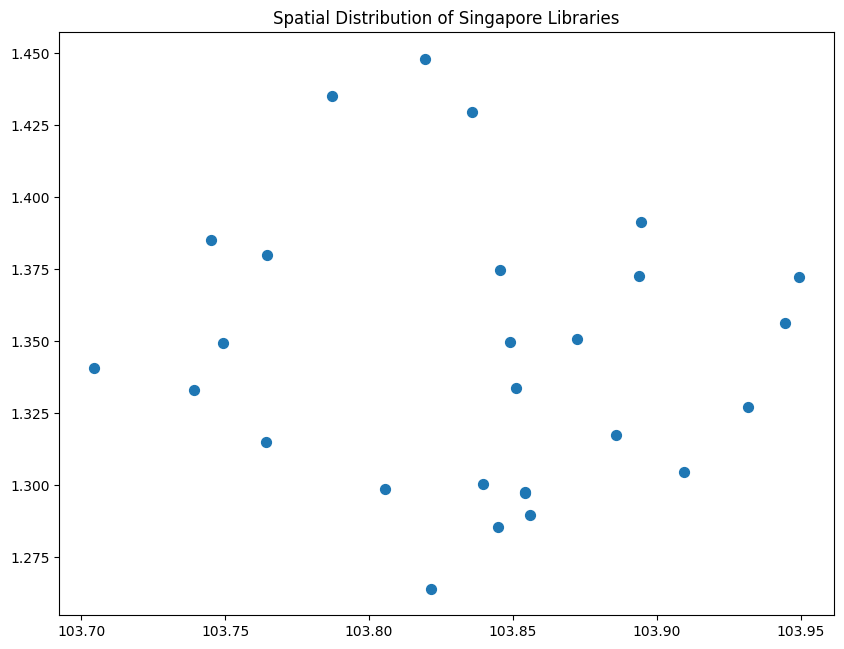

In [ ]:
#Visualize points


df_newlibraries.plot(figsize=(10, 10), markersize=50)

plt.title("Spatial Distribution of Singapore Libraries")
plt.show()

The spatial visualisation of the geometric coordinates is inconclusive by itself as it is difficult to determine whether the coordinates are accurately within Singapore land boundaries. Still, from a general standpoint, there are no visual outliers. More data will be needed from other datasets to verify geometric accuracy.

**Data quality:**  
Positive: The dataset is published by National Library Board (NLB), hence it serves as a reliable and accurate representation of location data for all public library locations in Singapore. Our exploration confirms that the geometry column contains valid 'POINT Z' coordinates in the WGS84 coordinate system. This therefore provides the exact geographical granularity needed to analyze proximity to residential student populations across different Planning Areas.
  

Negative:
Crucial data attributes are embedded within a single column, and wrong/duplicate values affect data quality.


In addition, the metadata obtained is insufficient for our work, providing the location information but not providing additional details like seating capacity etc. More data may be needed to further refine this dataset.  


In conclusion, this dataset is suitable for our project, as it provides an accurate representation of the geographical location of all the libraries in Singapore. The geometrical view of libraries also makes it easier to analyse with our other datasets.

### DS2: Master Plan 2019 Planning Area Boundary (No Sea)

**Description**: The dataset, downloaded from data.gov.sg, contains a geometric view of the planning areas designed by the Urban Redevelopment Authority (URA). This specific “No Sea” version excludes coastal waters, providing land-based Polygons as to where boundaries are drawn. This dataset links other datasets in relation to supply and student demand of the libraries, which is ultimately crucial in determining which specific residential zones may lack or are in need of bigger library infrastructure. By loading this data into a GeoDataFrame, we can verify its data structure.



In [ ]:
# Loading file
# We ensure CRS is consistent (EPSG:4326 for WGS84)
df_planning_area = gpd.read_file('/content/drive/MyDrive/SC3021_Datasets/MasterPlan2019PlanningAreaBoundaryNoSea.geojson'
)

**Exploration steps of DS2**

In [ ]:
print(df_planning_area.head())

   OBJECTID     PLN_AREA_N PLN_AREA_C CA_IND        REGION_N REGION_C  \
0         1          BEDOK         BD      N     EAST REGION       ER   
1         2       BOON LAY         BL      N     WEST REGION       WR   
2         3    BUKIT BATOK         BK      N     WEST REGION       WR   
3         4    BUKIT MERAH         BM      N  CENTRAL REGION       CR   
4         5  BUKIT PANJANG         BP      N     WEST REGION       WR   

            INC_CRC      FMEL_UPD_D    SHAPE.AREA     SHAPE.LEN  \
0  5F00E6FF084F3364  20191223152014  2.173397e+07  21864.234336   
1  C96AED188C00B2FC  20191223152014  8.282808e+06  18542.688792   
2  3BEC4C829160F28A  20191223152014  1.114018e+07  15236.442232   
3  4850795BB0B6A4F7  20191223152014  1.446120e+07  29161.409834   
4  656F87D23D6DAB02  20191223152014  9.019940e+06  15891.853279   

                                            geometry  
0  POLYGON ((103.93208 1.30555, 103.93208 1.30555...  
1  POLYGON ((103.72042 1.32824, 103.72066 1.3286

From this sample of data, we identified that planning area and region names are fully capitalised, which can cause issues when merging with datasets that use mixed casing. Each planning area should have a corresponding region and coordinates. We also noticed that planning areas are geometrically defined by geometric polygons rather than single points. Therefore, the geometric size of each planning area(defined by shape area in this dataset) may be useful in weighing resource allocation quantitatively. Other attributes such as INC_CRC and FMEL_UPD_D do not help with our analysis and hence should be parsed out.

In [ ]:
# Standardise casing to Title case to ensure successful merging with other datasets
df_planning_area['PLN_AREA_N'] = df_planning_area['PLN_AREA_N'].str.title()
df_planning_area['REGION_N'] = df_planning_area['REGION_N'].str.title()

# Convert shape area to M SQM for easier readability
df_planning_area['AREA_M_SQM'] = df_planning_area['SHAPE.AREA'] / 1000000

# Filter out redundant columns
df_planning_area = df_planning_area[['PLN_AREA_N', 'REGION_N', 'geometry', 'AREA_M_SQM']]

print(df_planning_area.head())

      PLN_AREA_N        REGION_N  \
0          Bedok     East Region   
1       Boon Lay     West Region   
2    Bukit Batok     West Region   
3    Bukit Merah  Central Region   
4  Bukit Panjang     West Region   

                                            geometry  AREA_M_SQM  
0  POLYGON ((103.93208 1.30555, 103.93208 1.30555...   21.733967  
1  POLYGON ((103.72042 1.32824, 103.72066 1.32865...    8.282808  
2  POLYGON ((103.76408 1.37001, 103.76385 1.37036...   11.140177  
3  POLYGON ((103.82361 1.26018, 103.82368 1.26018...   14.461199  
4  POLYGON ((103.77445 1.39029, 103.77444 1.39029...    9.019940  


In [ ]:
# Integrity Check: Check null counts
print("Check for null counts.")
null_count = df_planning_area.isnull().sum()
print("Null counts:\n", null_count)

# Uniqueness Check: Check for duplicate planning area names
print("\nCheck for duplicate planning area names.")
total_count = df_planning_area['PLN_AREA_N'].count()
print("Total count:", total_count)
distinct_count = df_planning_area['PLN_AREA_N'].nunique()
print("Distict count:", distinct_count)

Check for null counts.
Null counts:
 PLN_AREA_N    0
REGION_N      0
geometry      0
AREA_M_SQM    0
dtype: int64

Check for duplicate planning area names.
Total count: 55
Distict count: 55


Based on the above exploration, there are no null values and duplicate values, further confirming the reliability of this dataset. We also need to further visualise the statistical distribution of planning areas and planning regions across Singapore.

In [ ]:
#Identify largest and smallest region areas
largest_area = df_planning_area.loc[df_planning_area['AREA_M_SQM'].idxmax()]


smallest_area = df_planning_area.loc[df_planning_area['AREA_M_SQM'].idxmin()]

print(f"Largest Planning Area: {largest_area['PLN_AREA_N']} ({largest_area['AREA_M_SQM']:.2f} M sqm)")
print(f"Smallest Planning Area: {smallest_area['PLN_AREA_N']} ({smallest_area['AREA_M_SQM']:.2f} M sqm)")

# Check distribution of sizes
print("Distribution:\n",df_planning_area['AREA_M_SQM'].describe())

Largest Planning Area: Western Water Catchment (69.75 M sqm)
Smallest Planning Area: Museum (0.83 M sqm)
Distribution:
 count    55.000000
mean     14.271282
std      14.945837
min       0.829539
25%       6.629630
50%      10.100536
75%      16.649274
max      69.748336
Name: AREA_M_SQM, dtype: float64


From this exploration, we identified a huge scale discrepency between the largest planning area (69.75 M sqm) and the smallest planning area (0.83 M sqm). This proves to us that planning areas in Singapore are not planned particularly by land size, but rather by functional land use and intent. The Western Water Catchment area is designed for water utility land usage, the Museum area is designed for museum spaces. Due to the inconsistency of planning area sizes, we may have to look beyond land area for a more accurate analysis.

In [ ]:
# Check number of planning areas in each region
region_counts = df_planning_area['REGION_N'].value_counts()
print("Number of planning areas per region: ")
print(region_counts)

Number of planning areas per region: 
REGION_N
Central Region       22
West Region          12
North Region          8
North-East Region     7
East Region           6
Name: count, dtype: int64


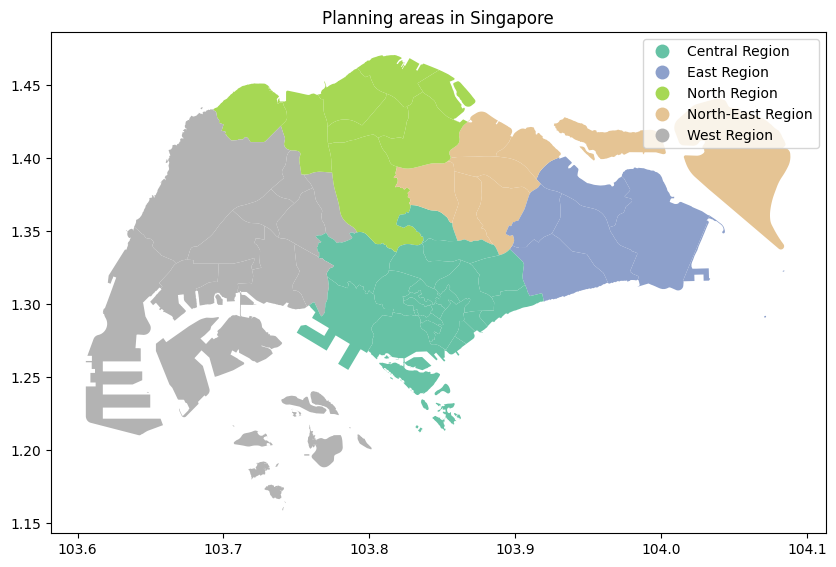

In [ ]:
#Visualize points
df_planning_area.plot(column="REGION_N",legend=True, cmap='Set2', figsize=(10, 10))

plt.title("Planning areas in Singapore")
plt.show()



  
**Quality of Data:**  
Positive: The dataset contains official boundaries drawn by the URA in 2019, which proves to be highly accurate. The "PLN_AREA_N" column provides the official name of each area, which will be the primary key for joining with our demographic and library data once normalised to Title Case. The geometric polygons also provide precise spatial boundaries of planning areas, which can help us move beyond 2D point-based analysis.
  
Negative: Although each planning area is theoretically designed to have a population of 150,000, our exploration revealed that planning areas are not geographically uniform. Planning area sizes alone therefore may not serve as accurate representations for library resource allocation.


In conclusion, this dataset is suitable for our project,as it can help link related datasets and provide spatial boundaries. When proceeding to use this dataset, we need to convert columns with string data types from full capitalisation to Mixed Case.
In addition, we are unable to simply use planning area sizes to determine library resource allocation. Finding additional data, such as residential student density per planning area, is essential in ensuring proper spatial equity and resource optimisation.

### DS3: Master Plan 2008 Subzone Boundary (No Sea)

**Description**: This dataset, acquired from the Singapore Master Plan 2008, contains 311 distinct subzones exluding sea areas, Each row outlines its corresponding planning area and region (REGION_N). The data is at a high level of granularity, hence, it enables for the systematic aggregation of data into broader Planning Area and Regions. The following code imports the data into a dataframe and displays the first five rows to verify the stored attribute and the consistency of the data records.

In [ ]:
# Loading file
df_2008SubZone = gpd.read_file("/content/drive/MyDrive/SC3021_Datasets/MP08_SUBZONE_NO_SEA_PL.shp")

print(df_2008SubZone.head())

   OBJECTID  SUBZONE_NO                  SUBZONE_N SUBZONE_C CA_IND  \
0         1           1  WOODLANDS REGIONAL CENTRE    WDSZ01      N   
1         2           1                     KRANJI    SKSZ01      N   
2         3           2                  TURF CLUB    SKSZ02      N   
3         4           7                   NEE SOON    YSSZ07      N   
4         5           9                YISHUN WEST    YSSZ09      N   

     PLN_AREA_N PLN_AREA_C      REGION_N REGION_C           INC_CRC  \
0     WOODLANDS         WD  NORTH REGION       NR  8877712517DEEC59   
1  SUNGEI KADUT         SK  NORTH REGION       NR  DE75F42EC0F86B2B   
2  SUNGEI KADUT         SK  NORTH REGION       NR  5D555DB858522781   
3        YISHUN         YS  NORTH REGION       NR  D5436FFE80750D15   
4        YISHUN         YS  NORTH REGION       NR  6CC6926FF0495D89   

  FMEL_UPD_D      X_ADDR      Y_ADDR   SHAPE_Leng    SHAPE_Area  \
0 2016-05-11  22571.2094  46698.8735  3254.343275  5.956521e+05   
1 2016-05-11

**Exploration steps for DS3**

In [ ]:
# Determine the number of subzones in 2010
total_subzones = len(df_2008SubZone)
print(f"Total Number of Subzones: {total_subzones}")

# Perform a categorical aggregation to determine the number of subzone in each planning area
subzones_per_pa = df_2008SubZone['PLN_AREA_N'].value_counts()

# Print the top 10 Areas with the most number of subzones
print("\nNumber of Subzones per Planning Area (Top 10):")
print(subzones_per_pa.head(10))

Total Number of Subzones: 311

Number of Subzones per Planning Area (Top 10):
PLN_AREA_N
BUKIT MERAH      17
QUEENSTOWN       15
TOA PAYOH        12
DOWNTOWN CORE    12
ANG MO KIO       10
JURONG EAST      10
ROCHOR           10
JURONG WEST       9
KALLANG           9
YISHUN            9
Name: count, dtype: int64


The attribute table contains 16 columns, including keys (SUBZONE_C, SUBZONE_N) and the corresponding planning area(PLN_AREA_N, PLN,_AREA_C). The presence of X_ADDR and Y_ADDR attributes provides the centroid coordinates.

In [ ]:
# Convert capitalized names to mixed case
df_2008SubZone['PLN_AREA_N'] = df_2008SubZone['PLN_AREA_N'].str.title()
df_2008SubZone['REGION_N'] = df_2008SubZone['REGION_N'].str.title()

# Filter out redundant columns, ensuring 'geometry' is retained for GeoDataFrame functionality
df_2008SubZone = df_2008SubZone[['SUBZONE_N', 'PLN_AREA_N', 'REGION_N', 'geometry']]

print(df_2008SubZone.head())

                   SUBZONE_N    PLN_AREA_N      REGION_N  \
0  WOODLANDS REGIONAL CENTRE     Woodlands  North Region   
1                     KRANJI  Sungei Kadut  North Region   
2                  TURF CLUB  Sungei Kadut  North Region   
3                   NEE SOON        Yishun  North Region   
4                YISHUN WEST        Yishun  North Region   

                                            geometry  
0  POLYGON ((22629.486 46980.246, 22683.012 46942...  
1  POLYGON ((20329.947 47234.988, 20333.366 47231...  
2  POLYGON ((21094.367 44815.121, 21099.854 44500...  
3  POLYGON ((26860.555 43913.328, 26839.719 43810...  
4  POLYGON ((28228.609 45792.488, 28223.039 45638...  


We retained the SUBZONE_N (Subzone Name), PLN_AREA_N (Planning Area Name, REGION_N (Region Name), and the geometry coordinates.

In [ ]:
# Check formatting
print(df_2008SubZone.info())

# Integrity Check: Check for null counts
print("\nCheck for Null Counts.")
print(df_2008SubZone.isnull().sum())

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   SUBZONE_N   311 non-null    object  
 1   PLN_AREA_N  311 non-null    object  
 2   REGION_N    311 non-null    object  
 3   geometry    311 non-null    geometry
dtypes: geometry(1), object(3)
memory usage: 9.8+ KB
None

Check for Null Counts.
SUBZONE_N     0
PLN_AREA_N    0
REGION_N      0
geometry      0
dtype: int64


We see that there are zero NULL values in the attribute columns . However, as it is based on the 2008 Master Plan, we acknowledge that it may lack newly reclaimed land or updated subzone divisions.

In [ ]:
# Calculate frequency of data entries per region

print("Frequency count of regions.")
print(df_2008SubZone['REGION_N'].value_counts())

Frequency count of regions.
REGION_N
Central Region       134
West Region           71
North Region          41
North-East Region     36
East Region           29
Name: count, dtype: int64


We see that subzones are distributed across five planning regions, where the central region holds the highest density, and the east holds the lowest density.

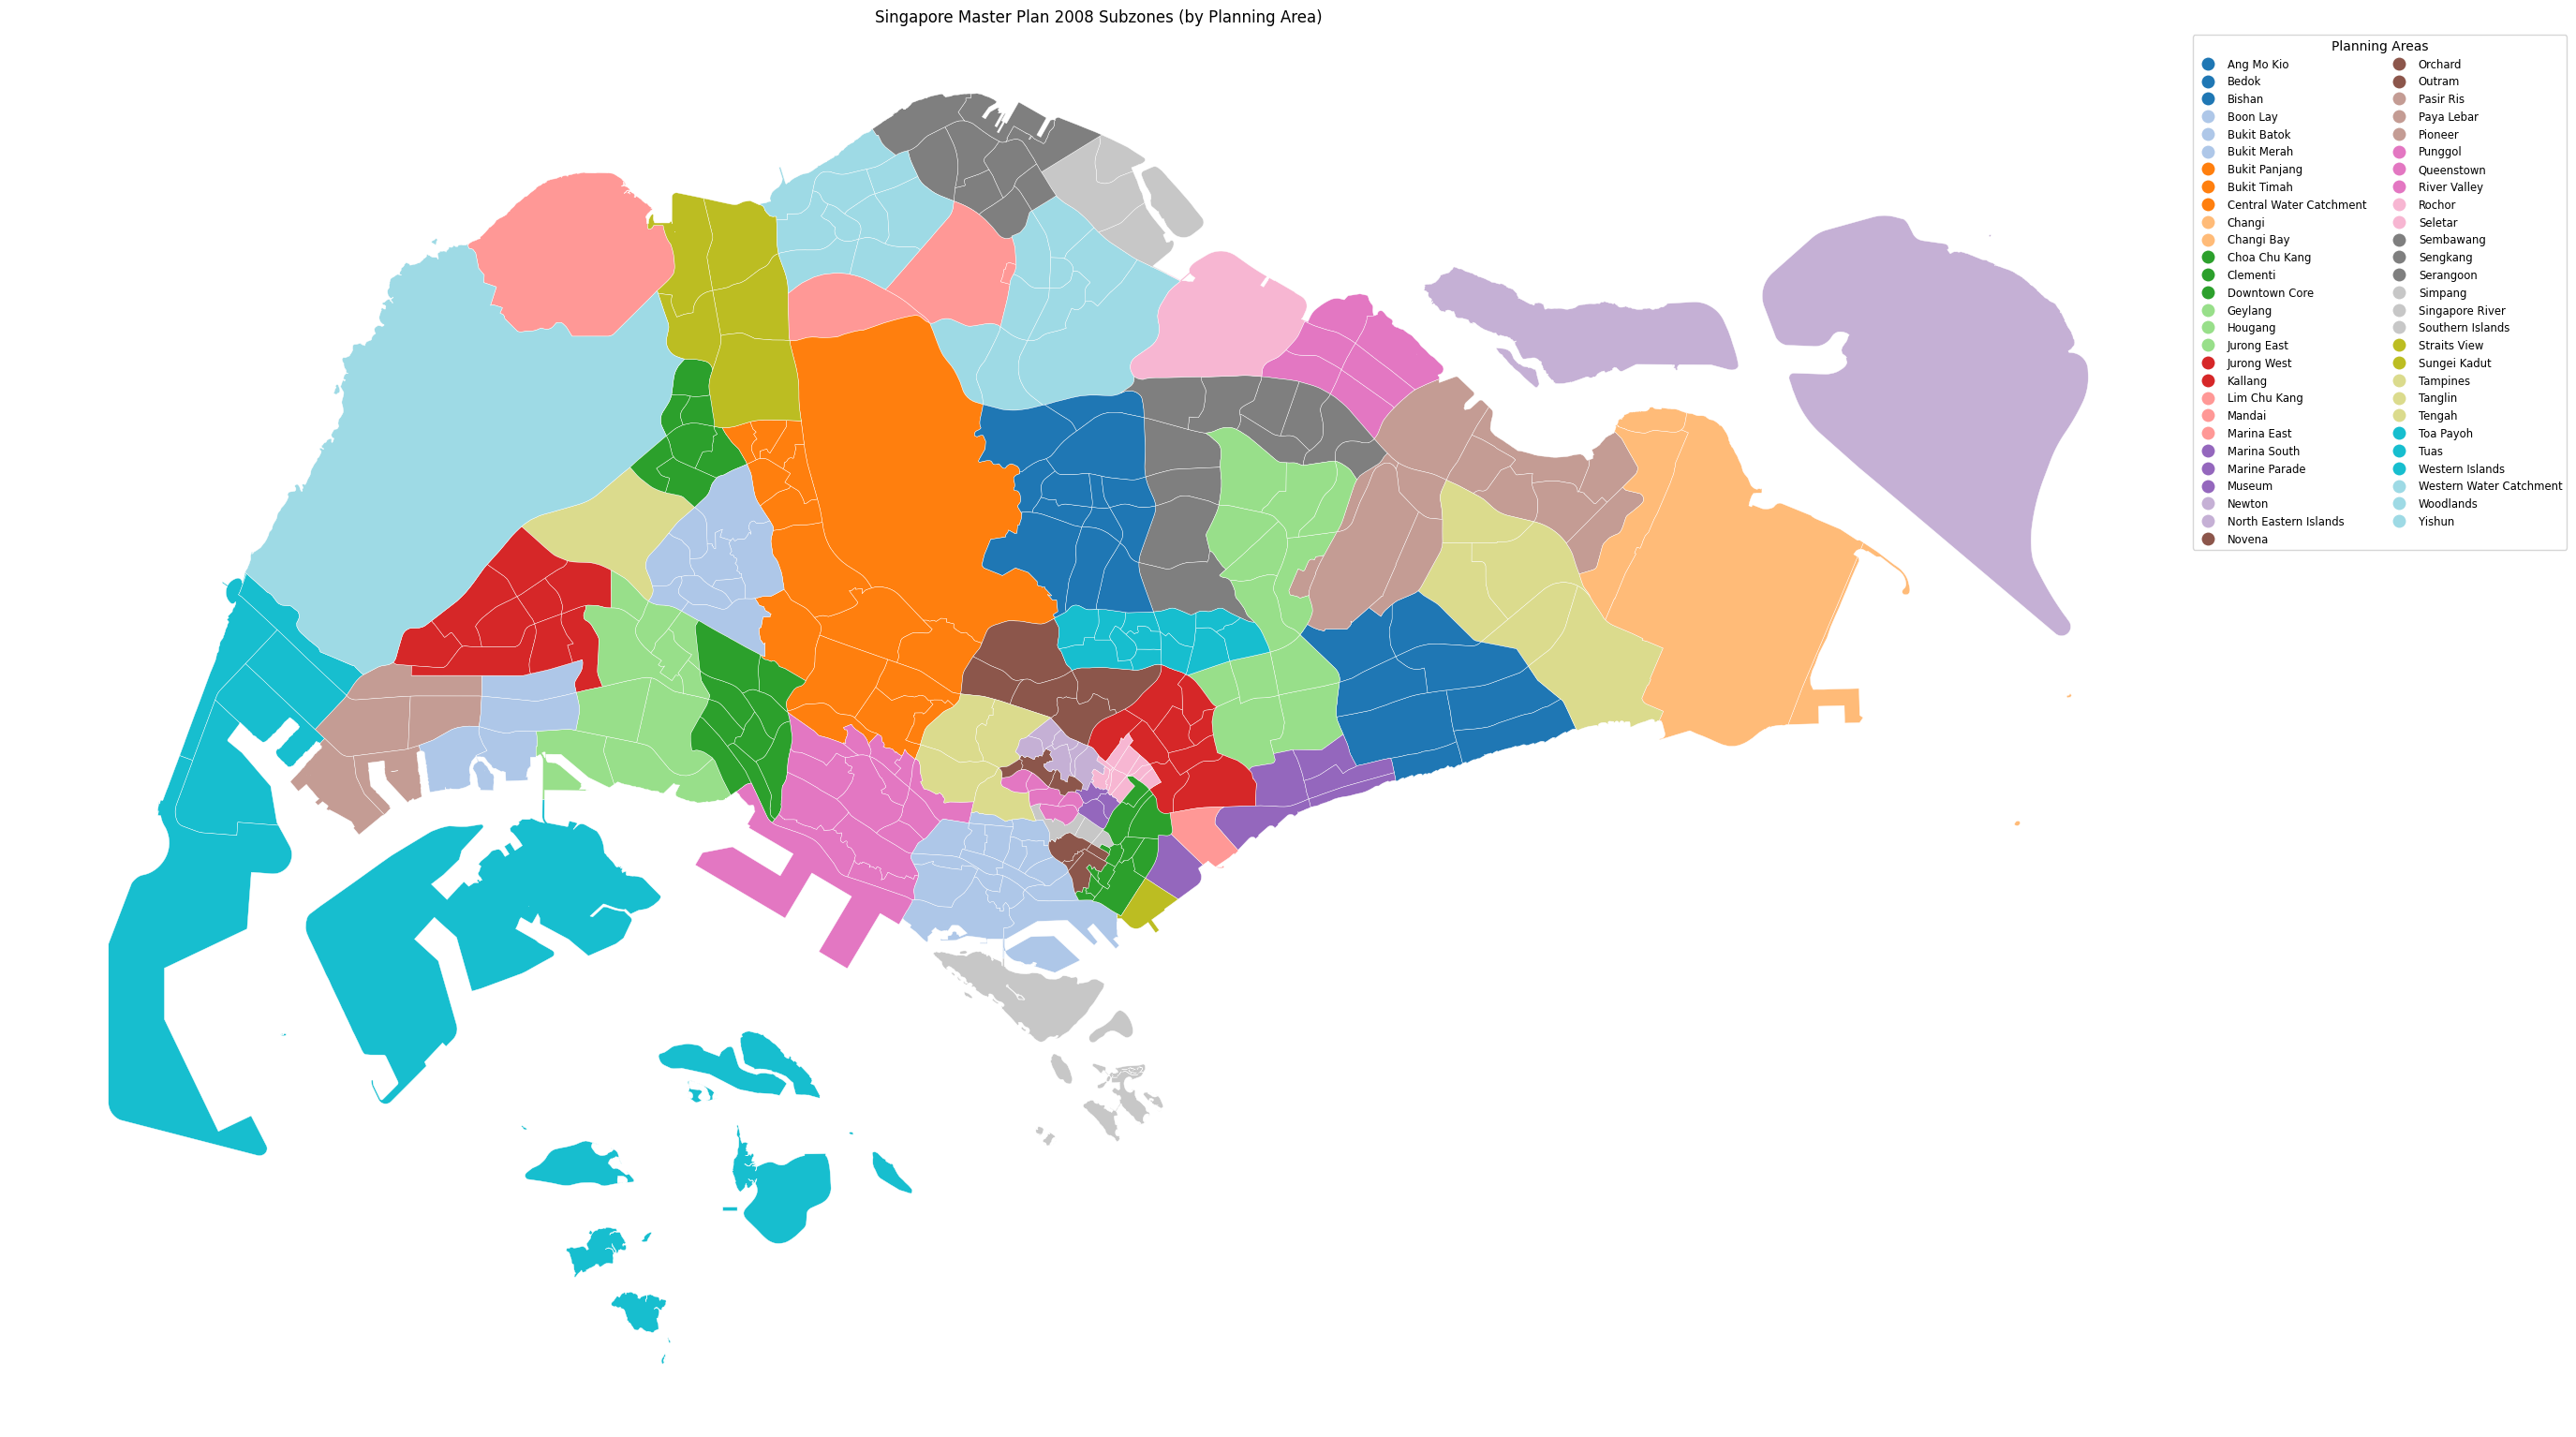

In [ ]:
# Retain important attributes for visualisation
df_2008SubZone = df_2008SubZone[['SUBZONE_N', 'PLN_AREA_N', 'REGION_N', 'geometry']]

fig, ax = plt.subplots(1, 1, figsize=(30, 30))

# Colour code based on column 'PLN_AREA_N' to visually identify boundaries
df_2008SubZone.plot(
    column='PLN_AREA_N',
    ax=ax,
    legend=True,
    legend_kwds={
        'title': "Planning Areas",
        'loc': 'upper left',
        'bbox_to_anchor': (1, 1),
        'ncol': 2,
        'fontsize': 'small'
        },
        cmap='tab20', # For better colour distinction
        edgecolor='white',
        linewidth=0.3,
        categorical=True)

plt.title("Singapore Master Plan 2008 Subzones (by Planning Area)")
plt.axis('off')
plt.show()

We identified the relationship between the subzone and their parent planning area by categorizing every subzone into its respective planning area. Moreover, we see that numerous Subzones are clustered into larger Planning Areas, where the largest planning areas are located in the western and northern parts of Singapore, and the smallest planning areas are concentrated within the Central area. This proves that the dataset is well defined, enabling us to link the units to the 2010 residential student count in later stages.

In [ ]:
# Identify unique Planning Area names to check for boundary changes
subZone2008Name = set(df_2008SubZone['PLN_AREA_N'].unique())
planningArea2019Name = set(df_planning_area['PLN_AREA_N'].unique())

# Identify areas not in 2008
missingIn2008 = planningArea2019Name - subZone2008Name

# Identify areas not in 2019
missingIn2019a = subZone2008Name - planningArea2019Name

print(f"Planning Areas in 2019 but NOT in 2008: {missingIn2008}")
print(f"Planning Areas in 2008 but NOT in 2019: {missingIn2019a}")

Planning Areas in 2019 but NOT in 2008: {'North-Eastern Islands'}
Planning Areas in 2008 but NOT in 2019: {'North Eastern Islands'}


From the output above, we observe a near perfect match between the 2010 and 2019 Planning Area names, with the exception of a minor formatting discrepancy. In the 2010 dataset, the name is recorded without a hyphen ("North Eastern Islands"), whereas the 2019 dataset includes it. Therefore, a standardization step is required to ensure these names are identical before merging student population counts.

In [ ]:
# Standardise naming conventions
df_2008SubZone['PLN_AREA_N'] = df_2008SubZone['PLN_AREA_N'].replace({'North Eastern Islands': 'North-Eastern Islands'})

In the following step, we utilized the symmetric difference operator (^) to identify any elements that exist in either the 2010 or 2019 datasets but are not shared by both. This allowed us to pinpoint the formatting discrapencies. By ensuring this operation returns an empty set, we can confirm that our data is synchronized.

In [ ]:
set_2008 = set(df_2008SubZone['PLN_AREA_N'].unique())
set_2019 = set(df_planning_area['PLN_AREA_N'].unique())

# Identify planning areas that are unique to each set
print(f"Remaining Mismatches: {set_2008 ^ set_2019}")

Remaining Mismatches: set()


We employed a Spatial Overlay analysis using a "Majority Rule" logic. By calculating the area where 2008 polygons overlap with 2019 polygons, we determine which Planning Area in 2019 "owns" the largest portion of the planning area in 2008. This allows us to detect any boundary redrawing, mergers, or name changes that would otherwise lead to skewed population data.

In [ ]:
df_2008_geo = df_2008SubZone[['PLN_AREA_N', 'geometry']].copy().to_crs(epsg=3414)
df_2008_geo.rename(columns={'PLN_AREA_N': 'PLANNING AREA 2008'}, inplace=True)

df_2019_geo = df_planning_area[['PLN_AREA_N', 'geometry']].copy().to_crs(epsg=3414)
df_2019_geo.rename(columns={'PLN_AREA_N': 'PLANNING AREA 2019'}, inplace=True)

# Slices the 2008 boundaries against the 2019 boundaries
overlay_08_19 = gpd.overlay(df_2008_geo, df_2019_geo, how='intersection', keep_geom_type=True)
overlay_08_19['piece_area'] = overlay_08_19.geometry.area

# Group by the old name and see which new name owns the most land
mapping_08_19 = (
    overlay_08_19.groupby(['PLANNING AREA 2008', 'PLANNING AREA 2019'])['piece_area']
    .sum()
    .reset_index()
    .sort_values('piece_area', ascending=False)
    .drop_duplicates('PLANNING AREA 2008')
)

# Filter out rows where the name stayed the same
actual_changes_08 = mapping_08_19[
    mapping_08_19['PLANNING AREA 2008'] != mapping_08_19['PLANNING AREA 2019']
]

pa_map_2008 = dict(zip(mapping_08_19['PLANNING AREA 2008'], mapping_08_19['PLANNING AREA 2019']))

if actual_changes_08.empty:
    print("No major Planning Area changes found.")
else:
    print(actual_changes_08[['PLANNING AREA 2008', 'PLANNING AREA 2019']])

No major Planning Area changes found.


**Data Quality**  
Positive: The dataset provides a high level of granularity. It enables us to standardize the boundaries across different time period.   
Negative: However, the dataset reflects the boundaries and landmass of the Master Plan 2008. The data does not account for subsequent land reclamation, and changes in the corresponding planning areas that occurred between 2010 and 2020.

**Conclusion**  
The dataset is suitable for our project, as its high level of granularity enables the mapping of 2008 subzones to 2020 planning areas. While it reflects the boundaries of its temporal scope and does not account for subsequent land reclamation, its high granuality makes it a suitable source for subzone-level spatial analysis. This high granularity of the dataset provides the framework needed to aligning 2010 residential student population with 2020 Planning Areas.

### DS4: Master Plan 2014 Subzone Boundary (No Sea)

**Description:** This geospatial dataset, downloaded from data.gov.sg, contains subzone boundaries from the 2014 Master Plan. It includes names of subzone, names of planning area, and their corresponding region. Hence, it provides a high level of granularity necessary to combine with student population for a 10 year student population projection in each planning area. The following code imports the file into a GeoDataFrame.

In [ ]:
# Load the dataset
df_2014SubZone = gpd.read_file("/content/drive/MyDrive/SC3021_Datasets/MP14_SUBZONE_NO_SEA_PL.shp")

# Print the first 5 tuples
print(df_2014SubZone.head())

   OBJECTID  SUBZONE_NO      SUBZONE_N SUBZONE_C CA_IND     PLN_AREA_N  \
0         1           2  PEOPLE'S PARK    OTSZ02      Y         OUTRAM   
1         2           2    BUKIT MERAH    BMSZ02      N    BUKIT MERAH   
2         3           3      CHINATOWN    OTSZ03      Y         OUTRAM   
3         4           4        PHILLIP    DTSZ04      Y  DOWNTOWN CORE   
4         5           5  RAFFLES PLACE    DTSZ05      Y  DOWNTOWN CORE   

  PLN_AREA_C        REGION_N REGION_C           INC_CRC FMEL_UPD_D  \
0         OT  CENTRAL REGION       CR  B4120D23006C932A 2016-05-11   
1         BM  CENTRAL REGION       CR  1C51019439A68700 2016-05-11   
2         OT  CENTRAL REGION       CR  0FF1661344C84AED 2016-05-11   
3         DT  CENTRAL REGION       CR  615D4EDDEF809F8E 2016-05-11   
4         DT  CENTRAL REGION       CR  72107B11807074F4 2016-05-11   

       X_ADDR      Y_ADDR   SHAPE_Leng     SHAPE_Area  \
0  28831.7807  29419.6457  1822.192718   93140.437642   
1  26360.7990  29384

**Exploration steps for DS4**

In [ ]:
# Determine the number of subzones in 2014
total_subzones = len(df_2014SubZone)
print(f"Total Number of Subzones: {total_subzones}")

# Perform a categorical aggregation to determine the number of subzone in each planning area
subzones_per_pa = df_2014SubZone['PLN_AREA_N'].value_counts()

# Print the top 10 Planning Areas with the most number of subzones
print("\nNumber of Subzones per Planning Area (Top 10):")
print(subzones_per_pa.head(10))

Total Number of Subzones: 323

Number of Subzones per Planning Area (Top 10):
PLN_AREA_N
BUKIT MERAH      17
QUEENSTOWN       15
DOWNTOWN CORE    12
TOA PAYOH        12
ANG MO KIO       12
JURONG EAST      10
ROCHOR           10
HOUGANG          10
YISHUN            9
SEMBAWANG         9
Name: count, dtype: int64


We see that the names of the subzones and planning areas are stored in uppercase, which needs to be standardized when combined with the census datasets that uses title casing.

In [ ]:
# Convert capitalized names to mixed case
df_2014SubZone['SUBZONE_N'] = df_2014SubZone['SUBZONE_N'].str.title()
df_2014SubZone['REGION_N'] = df_2014SubZone['REGION_N'].str.title()
df_2014SubZone['PLN_AREA_N'] = df_2014SubZone['PLN_AREA_N'].str.title()

print(df_2014SubZone.head(10))

   OBJECTID  SUBZONE_NO            SUBZONE_N SUBZONE_C CA_IND     PLN_AREA_N  \
0         1           2        People'S Park    OTSZ02      Y         Outram   
1         2           2          Bukit Merah    BMSZ02      N    Bukit Merah   
2         3           3            Chinatown    OTSZ03      Y         Outram   
3         4           4              Phillip    DTSZ04      Y  Downtown Core   
4         5           5        Raffles Place    DTSZ05      Y  Downtown Core   
5         6           4         China Square    OTSZ04      Y         Outram   
6         7          10          Tiong Bahru    BMSZ10      N    Bukit Merah   
7         8          12     Bayfront Subzone    DTSZ12      Y  Downtown Core   
8         9           4  Tiong Bahru Station    BMSZ04      N    Bukit Merah   
9        10           6        Clifford Pier    DTSZ06      Y  Downtown Core   

  PLN_AREA_C        REGION_N REGION_C           INC_CRC FMEL_UPD_D  \
0         OT  Central Region       CR  B4120D2300

Moreover, we observe that certain strings contain special characters. For instance, apostrophes in "People's Park".

In [ ]:
# Fix the "'S" issue using regex
df_2014SubZone['SUBZONE_N'] = df_2014SubZone['SUBZONE_N'].str.replace(r"(')([A-Z])", lambda sub: sub.group(1) + sub.group(2).lower(), regex=True)

We performed attribute-based filtering, thereby, "zooming in" to Subzone Name, Planning Area Name, Region Name and the coordinates of the subzones while removing other attributes that are eliminating irrelevant features.

In [ ]:
# Perform an attribute based filtering to "zoom in" by retaining relevant attribute
df_2014SubZone = df_2014SubZone[['SUBZONE_N', 'PLN_AREA_N', 'REGION_N', 'geometry']]

print(df_2014SubZone.head())

       SUBZONE_N     PLN_AREA_N        REGION_N  \
0  People's Park         Outram  Central Region   
1    Bukit Merah    Bukit Merah  Central Region   
2      Chinatown         Outram  Central Region   
3        Phillip  Downtown Core  Central Region   
4  Raffles Place  Downtown Core  Central Region   

                                            geometry  
0  POLYGON ((29099.021 29640.03, 29116.963 29625....  
1  POLYGON ((26750.092 29216.098, 26751.912 29173...  
2  POLYGON ((29161.201 29723.071, 29189.033 29704...  
3  POLYGON ((29814.107 29616.894, 29806.682 29593...  
4  POLYGON ((30137.768 29843.194, 30138.417 29841...  


We retained the SUBZONE_N (Subzone Name), PLN_AREA_N (Planning Area Name, REGION_N (Region Name), and the geometry coordinates.

In [ ]:
# Check formatting
print(df_2014SubZone.info())

# Integrity Check: Check for null counts
print("Check for null counts")
print(df_2014SubZone.isnull().sum())

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 323 entries, 0 to 322
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   SUBZONE_N   323 non-null    object  
 1   PLN_AREA_N  323 non-null    object  
 2   REGION_N    323 non-null    object  
 3   geometry    323 non-null    geometry
dtypes: geometry(1), object(3)
memory usage: 10.2+ KB
None
Check for null counts
SUBZONE_N     0
PLN_AREA_N    0
REGION_N      0
geometry      0
dtype: int64


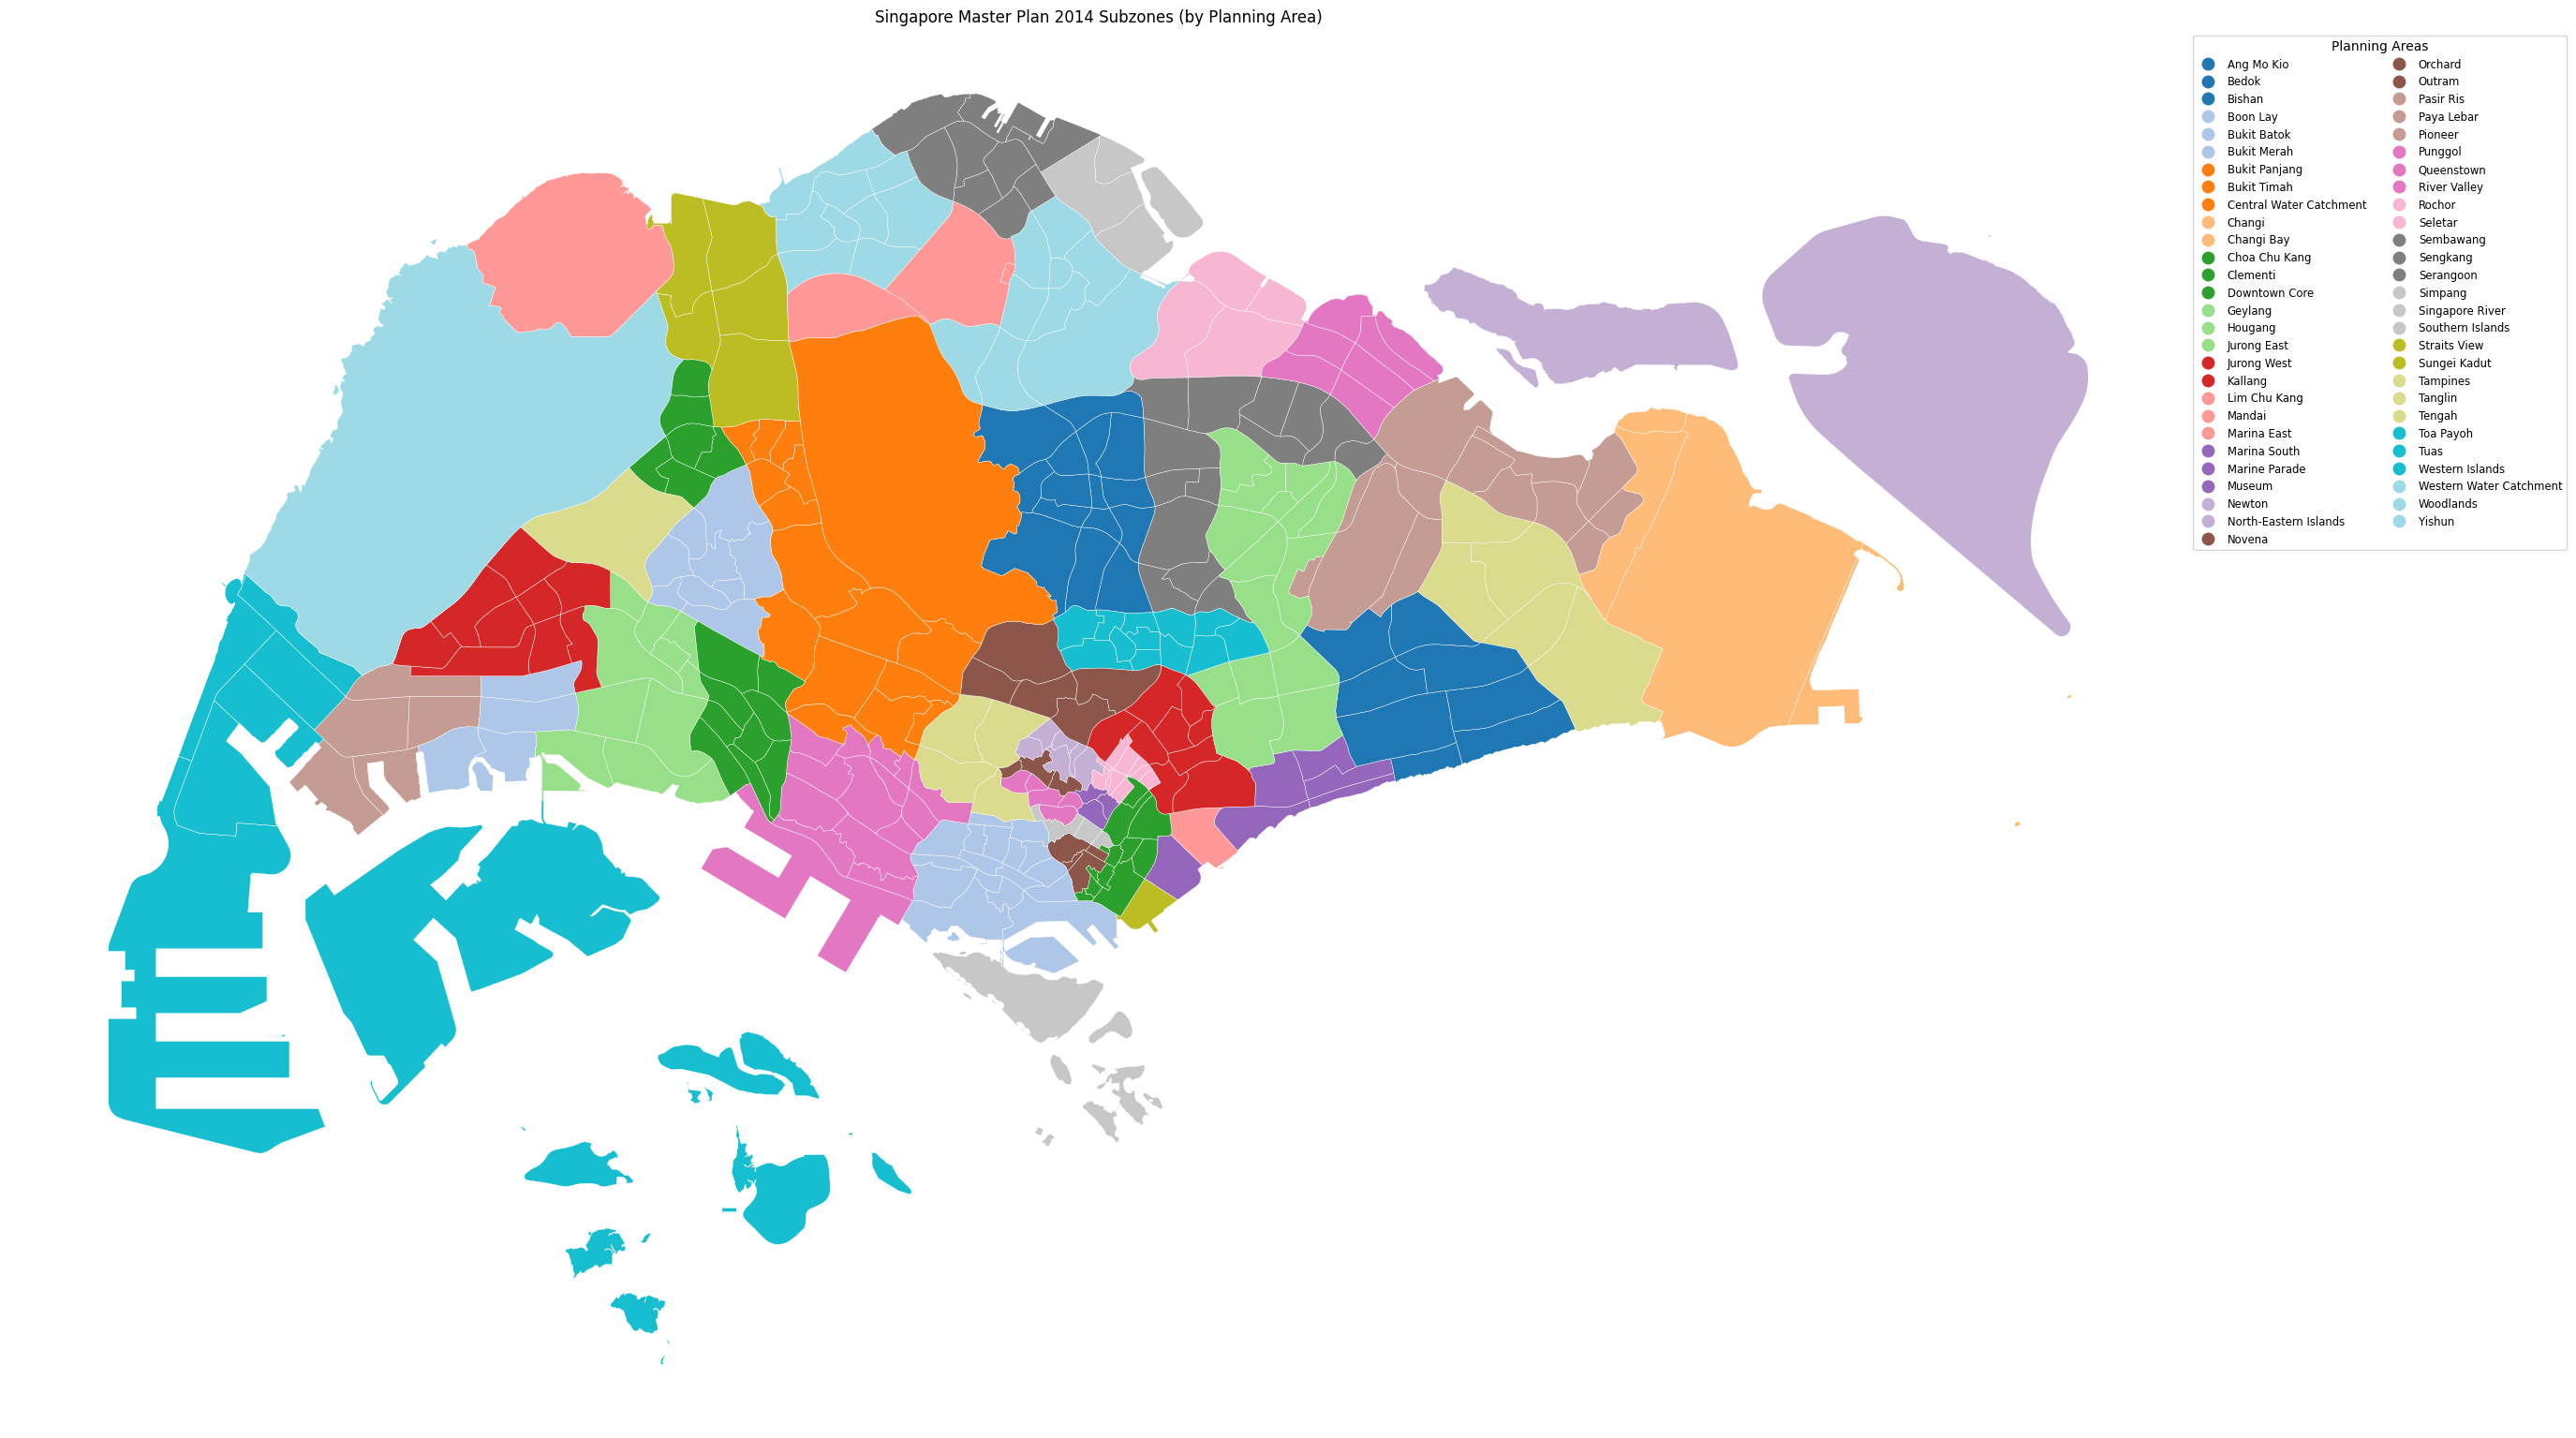

In [ ]:
# Retain important attributes for visualisation
df_2014SubZone = df_2014SubZone[['SUBZONE_N', 'PLN_AREA_N', 'REGION_N', 'geometry']]

fig, ax = plt.subplots(1, 1, figsize=(30, 30))
df_2014SubZone.plot(column='PLN_AREA_N', ax=ax, legend=True,
        legend_kwds={'title': "Planning Areas", 'loc': 'upper left', 'bbox_to_anchor': (1, 1), 'ncol': 2, 'fontsize': 'small'},
        cmap='tab20', edgecolor='white', linewidth=0.3, categorical=True)

plt.title("Singapore Master Plan 2014 Subzones (by Planning Area)")
plt.axis('off')
plt.show()

In [ ]:
PlanningArea2014Name = set(df_2014SubZone['PLN_AREA_N'].unique())
planningArea2019Name = set(df_planning_area['PLN_AREA_N'].unique())

# Find areas not in 2014
missingIn2014 = planningArea2019Name - PlanningArea2014Name

# Find areas not in 2019
missingIn2019b = PlanningArea2014Name - planningArea2019Name

print(f"Planning Areas in 2019 but NOT in 2014: {missingIn2014}")
print(f"Planning Areas in 2014 but NOT in 2019: {missingIn2019b}")

Planning Areas in 2019 but NOT in 2014: set()
Planning Areas in 2014 but NOT in 2019: set()


From the output above, we observe that the Planning Area names are sychronized between the 2014 Master Plan and the 2019 Master Plan. However, as noted in our previous exploration, it does not account for subzone redrawing. To ensure that student population, categorised by Planning Area, in 2014 is accurately projected towards 2030, we must still account for potential boundary revision.

In [ ]:
# Standardize 2014 Data
df_2014_geo = df_2014SubZone[['PLN_AREA_N', 'geometry']].copy().to_crs(epsg=3414)
df_2014_geo.rename(columns={'PLN_AREA_N': 'PLANNING AREA 2014'}, inplace=True)

# Standardize 2019 Data
df_2019_geo = df_planning_area[['PLN_AREA_N', 'geometry']].copy().to_crs(epsg=3414)
df_2019_geo.rename(columns={'PLN_AREA_N': 'PLANNING AREA 2019'}, inplace=True)

# This slices the 2014 boundaries against the 2019 boundaries
overlay_14_19 = gpd.overlay(df_2014_geo, df_2019_geo, how='intersection', keep_geom_type=True)
overlay_14_19['piece_area'] = overlay_14_19.geometry.area

# Find which 2019 name owns the most land for every 2014 name
mapping_14_19 = (
    overlay_14_19.groupby(['PLANNING AREA 2014', 'PLANNING AREA 2019'])['piece_area']
    .sum()
    .reset_index()
    .sort_values('piece_area', ascending=False)
    .drop_duplicates('PLANNING AREA 2014')
)

# Filter out rows where the name is identical
actual_changes_14 = mapping_14_19[
    mapping_14_19['PLANNING AREA 2014'] != mapping_14_19['PLANNING AREA 2019']
]

pa_map_2014 = dict(zip(mapping_14_19['PLANNING AREA 2014'], mapping_14_19['PLANNING AREA 2019']))

if actual_changes_14.empty:
    print("No major Planning Area changes found.")
else:
    print(actual_changes_14[['PLANNING AREA 2014', 'PLANNING AREA 2019']])

No major Planning Area changes found.


**Quality of Data**  
Positive: As the dataset is from the Urban Redevelopment Agency, the polygon accuracy is high, ensuring reliable spatial joins.

Negative: The Master Plan boundary datasets provide the geometric shape of a planning area but do not indicate the primary use of the planning area, for example, Residential, Commercial or Industrial.

**Conclusion**  
We consider the dataset essential, whereby, we will use Spatial Join method during data preparation to remap these 2014 subzones into 2019 Planning Areas, thereby, ensuring that "absorbed" areas do not result in null values in our 2030 projection model.

###DS5: Resident Students Aged 5 Years and Over by Planning Area of Residence and Usual Mode of Transport to School (Census of Population 2020)

**Description:** The data specifies the student population categorised Planning Area of residence. It provides an understanding of resident students aged 5 and above who reside within each geographic boundary. While the data includes the transportation modes, to evaluate the pressure placed on the public libraries, it is used as a quantitative measurement of the student density in each geographical boundary.  
  



In [ ]:
df_student = pd.read_csv('/content/drive/MyDrive/SC3021_Datasets/ResidentStudent.csv')

print(df_student.head())

# Rename the appropriate columns
df_student = df_student.rename(columns={'Number': 'Planning Area'})
df_student = df_student.rename(columns={'Total': 'Resident Student'})

# Get the column headers
df_column_headers = df_student.columns.tolist()
print(df_column_headers)

        Number   Total  PublicBusOnly  MRT_LRTOnly  MRT_LRTandPublicBusOnly  \
0        Total  715209         157002        50406                   164678   
1   Ang Mo Kio   24559           6740         1426                     5523   
2        Bedok   43667           9837         2484                     9419   
3       Bishan   15369           2837         1345                     4010   
4  Bukit Batok   27271           7312         1891                     6463   

  OthercombinationsofMRT_LRTorPublicBus Taxi_PrivateHireCarOnly  CarOnly  \
0                                 18766                    4670    96498   
1                                   260                      95     3095   
2                                   791                     434     8128   
3                                   174                     118     3073   
4                                   341                     141     3444   

   PrivateCharteredBus_VanOnly Lorry_PickupOnly Motorcycle_ScooterOn

We recognise that the dataset contains 13 attributes, which are not all relevant to our analysis. Therefore, we included only the relevant data for further processing which are the planning area and student population.

In [ ]:
# Only select the relevant rows and columns

# Remove only the 'Total' row
df_student = df_student[df_student['Planning Area'] != 'Total'].copy()

# Select the relevant columns
df_student_selected = df_student[['Planning Area', 'Resident Student']]
print(df_student_selected.head())

  Planning Area  Resident Student
1    Ang Mo Kio             24559
2         Bedok             43667
3        Bishan             15369
4   Bukit Batok             27271
5   Bukit Merah             22017


**Exploration steps for DS5**

We perform some data profiling to better understand the distinct planning areas it covers and the student population range recorded in the dataset

In [ ]:
# Print resident student population per planning area
print(df_student_selected)

    Planning Area  Resident Student
1      Ang Mo Kio             24559
2           Bedok             43667
3          Bishan             15369
4     Bukit Batok             27271
5     Bukit Merah             22017
6   Bukit Panjang             27319
7     Bukit Timah             16698
8   Choa Chu Kang             38478
9        Clementi             15747
10  Downtown Core               223
11        Geylang             16109
12        Hougang             36576
13    Jurong East             12359
14    Jurong West             51547
15        Kallang             14090
16  Marine Parade              8159
17         Novena              8466
18         Outram              2270
19      Pasir Ris             29067
20        Punggol             37071
21     Queenstown             14233
22   River Valley              1952
23      Sembawang             21005
24       Sengkang             53458
25      Serangoon             18855
26       Tampines             43175
27        Tanglin           

In [ ]:
# Number of planning areas
distinct_planning_areas = df_student_selected['Planning Area'].unique()
print(distinct_planning_areas)
num_planning_areas = df_student_selected['Planning Area'].nunique()
print(f"Number of planning areas: ",num_planning_areas)


['Ang Mo Kio' 'Bedok' 'Bishan' 'Bukit Batok' 'Bukit Merah' 'Bukit Panjang'
 'Bukit Timah' 'Choa Chu Kang' 'Clementi' 'Downtown Core' 'Geylang'
 'Hougang' 'Jurong East' 'Jurong West' 'Kallang' 'Marine Parade' 'Novena'
 'Outram' 'Pasir Ris' 'Punggol' 'Queenstown' 'River Valley' 'Sembawang'
 'Sengkang' 'Serangoon' 'Tampines' 'Tanglin' 'Toa Payoh' 'Woodlands'
 'Yishun' 'Others']
Number of planning areas:  31


Overall, this dataset only provides student population data for 30 planning area in Singapore, hence the completeness of this dataset is not adequate for the task at hand.


**Quality of Data:**  
Positive:
 Because the dataset is derived from the Census of Population 2020, it is representative of the geographical area. Moreover, as it is a mandatory national exercise, the data minimizes bias, ensuring that the Total Student count for each planning area is the actual count rather than statistical estimate or a sample.
   
Negative:
Comprehensiveness of the dataset is inadequate for our task. The only attributes that we found relevant to our project are 'Planning Area' and 'Resident Student', other important attributes such as age distribution is not included. Since the underlying data source is transport, it would be harder to justify using a transport-based total to calculate a library-based need. It introduces collateral bias if a student doesn't travel to school (e.g., they study fully online or are on a gap year but still using libraries), they might not fully represent the resident student population in 2020 accurately.

The data was also consolidated in 2020. Hence, in fast developing areas like Tengah and Punggol, the student population has likely surged significantly since its publication. Using the dataset might underestimate the demand in these non-mature estates. Hence, the conclusion derived may reflect the scarcity of 2020 rather than that of the present.  


  


**Conclusion for DS5**

We disregard DS5 from further consideration as it is incomplete in several regards, which results in too small an amount of data for the task at hand.


###DS6: Resident Students Aged 5 Years and Over by Planning Area of Residence and Level of Education Attending (Census of Population 2020)

**Description:** This dataset partitions resident student population in Singapore aged 5 years and over into disjoint Planning Areas. The data is further segmented by the level of education being attended, offering insights into the demand within each planing area. For the purpose of our analysis, we focus on the total student count per planning area.

**Exploration steps for DS6**

In [ ]:
df_student2020 = pd.read_csv('/content/drive/MyDrive/SC3021_Datasets/ResidentStudents2020.csv')

# Return the first five rows
print(df_student2020.head())

        Number   Total  Pre_Primary  Primary  Secondary  \
0        Total  719839        55993   245931     174298   
1   Ang Mo Kio   24714         1857     8066       5628   
2        Bedok   43976         3290    14572      10517   
3       Bishan   15580          840     5012       3676   
4  Bukit Batok   27407         2077     8485       6604   

   Post_Secondary_Non_Tertiary  PolytechnicDiploma  \
0                        56663               72676   
1                         2131                2832   
2                         3309                3923   
3                         1431                1344   
4                         2592                2686   

  ProfessionalQualificationandOtherDiploma  University  
0                                    11593      102685  
1                                      527        3674  
2                                      580        7785  
3                                      223        3056  
4                                  

For better readability, we renamed the attributes in DS6 by renaming the 'Number' and 'Total' attribute name to 'Planning Area' and '2020 Resident Students'. This ensure that column names are unique within the final merged table. Since multiple datasets (DS6, DS7, DS8 & DS9) originally used generic headers like "Total" and "Number," keeping these names would cause a conflict during the merge.

In [ ]:
# Rename the columns to ensure unique names and facilitate data integration at a later stage
df_student2020 = df_student2020.rename(columns={
    'Number': 'Planning Area',
    'Total':'2020 Resident Students'})

# Get the column headers
print(df_student2020.columns.tolist())

['Planning Area', '2020 Resident Students', 'Pre_Primary', 'Primary', 'Secondary', 'Post_Secondary_Non_Tertiary', 'PolytechnicDiploma', 'ProfessionalQualificationandOtherDiploma', 'University']


This exploration identifies 25 Planning Areas that exist in DS1 but show zero resident student population in the 2020 Census. This includes industrial areas, catchment areas, and developing towns. Furthermore, historical residential areas such as Singapore River, Rochor, and Newton appear to have been omitted in the 2020 Census. On the other hand, the census includes aggregate labels like 'Total' and 'Others', which do not point to any specific planning areas.

In [ ]:
planningArea2019Name = set(df_planning_area['PLN_AREA_N'].unique())
planningArea2020CensusName = set(df_student2020['Planning Area'].unique())

# Find names that exist in 2010 Census but NOT in DS1
missingFromCensus2010 = planningArea2019Name - planningArea2020CensusName
print(f"{len(missingFromCensus2010)} Planning Areas in 2019 Map missing from 2020 Census: {missingFromCensus2010}")

# Find names that exist in the DS1 but NOT in 2010 Census
missingFromMap2019 = planningArea2020CensusName - planningArea2019Name
print(f"{len(missingFromMap2019)} Planning Areas in 2020 Census missing from 2019 Map: {missingFromMap2019}")

25 Planning Areas in 2019 Map missing from 2020 Census: {'Rochor', 'Western Islands', 'Newton', 'Tengah', 'Changi Bay', 'Paya Lebar', 'Orchard', 'Pioneer', 'North-Eastern Islands', 'Central Water Catchment', 'Sungei Kadut', 'Changi', 'Tuas', 'Seletar', 'Boon Lay', 'Marina East', 'Southern Islands', 'Singapore River', 'Straits View', 'Mandai', 'Simpang', 'Museum', 'Marina South', 'Lim Chu Kang', 'Western Water Catchment'}
2 Planning Areas in 2020 Census missing from 2019 Map: {'Others', 'Total'}


By removing the 'Total' and 'Others' rows, we eliminate aggregated values that lack a specific geographical boundary. This structuring is necessary because the 'Others' row represents a collection of sub-zones rather than a specific planning area, hence, it lacks the granuality demanded by the project.

In [ ]:
# Peform a Record-based filtering by "zooming in" to defined Planning Area
df_student2020 = df_student2020[(df_student2020['Planning Area'] != 'Total') & (df_student2020['Planning Area'] != 'Others')]

print(df_student2020.head())

  Planning Area  2020 Resident Students  Pre_Primary  Primary  Secondary  \
1    Ang Mo Kio                   24714         1857     8066       5628   
2         Bedok                   43976         3290    14572      10517   
3        Bishan                   15580          840     5012       3676   
4   Bukit Batok                   27407         2077     8485       6604   
5   Bukit Merah                   22195         1857     8530       4992   

   Post_Secondary_Non_Tertiary  PolytechnicDiploma  \
1                         2131                2832   
2                         3309                3923   
3                         1431                1344   
4                         2592                2686   
5                         1739                1892   

  ProfessionalQualificationandOtherDiploma  University  
1                                      527        3674  
2                                      580        7785  
3                                      223     

We performed attribute-based filtering, thereby, "zooming in" to "Planning Area" and "2020 Resident Students" and removing attributes that do not contribute to the regression analysis in the Data Analysis stage.

In [ ]:
df_student2020 = df_student2020[['Planning Area', '2020 Resident Students']]

print(df_student2020)

    Planning Area  2020 Resident Students
1      Ang Mo Kio                   24714
2           Bedok                   43976
3          Bishan                   15580
4     Bukit Batok                   27407
5     Bukit Merah                   22195
6   Bukit Panjang                   27475
7     Bukit Timah                   17021
8   Choa Chu Kang                   38707
9        Clementi                   15910
10  Downtown Core                     253
11        Geylang                   16226
12        Hougang                   36858
13    Jurong East                   12449
14    Jurong West                   51760
15        Kallang                   14208
16  Marine Parade                    8283
17         Novena                    8562
18         Outram                    2284
19      Pasir Ris                   29268
20        Punggol                   37190
21     Queenstown                   14353
22   River Valley                    1987
23      Sembawang                 

**Quality of data**  
Positive: As a national census, this is the most reliable source for resident student population distributions. Since the underlying data source is education level,  it would be easier to justify using an education-based total to calculate the library-based need for students.

Negative: It was conducted during the COVID-19 pandemic. Due to lockdowns and movement regulations during the pandemic, there may be shifts in household occupancy. For example, some resident students may have been staying with extended family or in different temporary accommodations rather than their usual place of residence during the circuit breaker period. In our regression model, this could lead to an outlier, thereby, affecting the slope of the 2030 projection.

**Conclusion**

We deem DS6 adequate for our analysis. While the data was collected during the COVID-19 pandemic, which might introduce some outliers in our regression model, it provides a comprehensive and reliable snapshot of the resident student population by education level, making it suitable for calculating library-based needs for students.

### DS7: Resident Students Aged 5 Years and Over by Planning Area and Level of Education Attending (Census of Population 2010)

**Description:** This dataset from the Census of Population 2010 provides a comprehensive record of the resident student population in Singapore. It outlines the distribution of resident students aged 5 years and older across the planning areas, categorized by their Level of Education.

**Exploration steps for DS7**

In [ ]:
df_student2010 = pd.read_csv('/content/drive/MyDrive/SC3021_Datasets/ResidentStudents2010.csv')

# Return the first five rows
print(df_student2010.head())

        Number   Total  Pre_Primary  Primary  Secondary  \
0        Total  796548        61492   282150     231992   
1   Ang Mo Kio   31023         2501    10897       8754   
2        Bedok   57802         4103    20171      15944   
3       Bishan   20922         1562     6490       5711   
4  Bukit Batok   33277         2372    11574       9601   

   Post_Secondary_Non_Tertiary Polytechnic  \
0                        55935       79708   
1                         2102        2966   
2                         4364        6343   
3                         1704        2274   
4                         2708        3202   

  ProfessionalQualificationAndOtherDiploma  University  
0                                    14885       70386  
1                                      595        3208  
2                                     1326        5550  
3                                      357        2824  
4                                      598        3224  


For better readability, we renamed the attributes in DS7 by renaming the 'Number' and 'Total' attribute name to 'Planning Area' and '2010 Resident Students'. This ensure that column names are unique within the final merged table. Since multiple datasets (DS6, DS7, DS8 & DS9) originally used generic headers like "Total" and "Number," keeping these names would cause a conflict during the merge.

In [ ]:
# Rename the columns to ensure unique names and facilitate data integration at a later stage
df_student2010 = df_student2010.rename(columns={
    'Number': 'Planning Area',
    'Total':'2010 Resident Students'})

# Get the column headers
df_column_headers2010 = df_student2010.columns.tolist()
print(f"Column Headers \n {df_column_headers2010}")

Column Headers 
 ['Planning Area', '2010 Resident Students', 'Pre_Primary', 'Primary', 'Secondary', 'Post_Secondary_Non_Tertiary', 'Polytechnic', 'ProfessionalQualificationAndOtherDiploma', 'University']


We observe that 20 Planning Areas, including industrial areas, and catchment areas, exist in DS1 but have no recorded resident student population in the 2010 Census. Conversely, the 2010 Census includes a generic 'Others' category that does not correspond to any defined geographical boundary on the 2019 Map. This indicates that while the map covers the entire land area of Singapore, the student population is concentrated in specific residential planning areas, leaving industrial and protected zones with null values in the 2030 projection.

In [ ]:
planningArea2019Name = set(df_planning_area['PLN_AREA_N'].unique())
planningArea2010Name = set(df_student2010['Planning Area'].unique())

# Find names that exist in 2010 Census but NOT in DS1
missingFromCensus2010 = planningArea2019Name - planningArea2010Name
print(f"{len(missingFromCensus2010)} Planning Areas in 2019 Map missing from 2010 Census: {missingFromCensus2010}")

# Find names that exist in the DS1 but NOT in 2010 Census
missingFromMap2019 = planningArea2010Name - planningArea2019Name
print(f"{len(missingFromMap2019)} Planning Areas in 2010 Census missing from 2019 Map: {missingFromMap2019}")

20 Planning Areas in 2019 Map missing from 2010 Census: {'Western Islands', 'Tengah', 'Changi Bay', 'Paya Lebar', 'Orchard', 'Pioneer', 'North-Eastern Islands', 'Central Water Catchment', 'Sungei Kadut', 'Tuas', 'Seletar', 'Boon Lay', 'Marina East', 'Southern Islands', 'Straits View', 'Simpang', 'Museum', 'Marina South', 'Lim Chu Kang', 'Western Water Catchment'}
2 Planning Areas in 2010 Census missing from 2019 Map: {'Others', 'Total'}


We performed attribute-based filtering, thereby, "zooming in" to "Planning Area" and "2010 Resident Students" and removing attributes that do not contribute to the regression analysis in the Data Analysis stage.

In [ ]:
# Perform an Attribute-based filtering by zooming in by retaining only relevant Attribute
df_student2010 = df_student2010[['Planning Area', '2010 Resident Students']]

print(df_student2010)

      Planning Area  2010 Resident Students
0             Total                  796548
1        Ang Mo Kio                   31023
2             Bedok                   57802
3            Bishan                   20922
4       Bukit Batok                   33277
5       Bukit Merah                   23013
6     Bukit Panjang                   31421
7       Bukit Timah                   15893
8            Changi                     529
9     Choa Chu Kang                   46661
10         Clementi                   15674
11    Downtown Core                     449
12          Geylang                   21532
13          Hougang                   48174
14      Jurong East                   17753
15      Jurong West                   59977
16          Kallang                   15606
17           Mandai                     323
18    Marine Parade                    8513
19           Newton                    1114
20           Novena                    8218
21           Outram             

By removing the 'Total' and 'Others' rows, we eliminate aggregated values that lack a specific geographical boundary. This structuring is necessary because the 'Others' row represents a collection of sub-zones rather than a specific planning area, hence, it lacks the granuality demanded by the project.

In [ ]:
# Peform a Record-based filtering by "zooming in" to defined Planning Area
df_student2010 = df_student2010[(df_student2010['Planning Area'] != 'Total') & (df_student2010['Planning Area'] != 'Others')]

print(df_student2010)

      Planning Area  2010 Resident Students
1        Ang Mo Kio                   31023
2             Bedok                   57802
3            Bishan                   20922
4       Bukit Batok                   33277
5       Bukit Merah                   23013
6     Bukit Panjang                   31421
7       Bukit Timah                   15893
8            Changi                     529
9     Choa Chu Kang                   46661
10         Clementi                   15674
11    Downtown Core                     449
12          Geylang                   21532
13          Hougang                   48174
14      Jurong East                   17753
15      Jurong West                   59977
16          Kallang                   15606
17           Mandai                     323
18    Marine Parade                    8513
19           Newton                    1114
20           Novena                    8218
21           Outram                    1833
22        Pasir Ris             

**Quality of Data:**  
Positive: The datasets are derived from the Census of Population 2010, which provides the most comprehensive snapshot of the student demographic in Singapore. The data is also granularly categorised by level of education, allowing us for a targeted analysis of specific age cohorts, and create more accurate projections.

Negative: The data was consolidated in 2010 respectively. There are significant realignments in Planning Area boudnaries that have occured in between. This could mean that geographical definitions may not perfectly align with our 2019 Master Plan Boundaries.

**Conclusion for DS7**

We deem DS7 adequate for our analytical tasks. The combined data allows for a clear analysis of growth trends over time and across planning areas. While the integration revealed 5 Planning Areas with NULL values in 2020, we have identified these as potential changes in boundaries. If NULL values in specific planning areas persists after standardization, we will exclude these discontinued areas from the growth velocity model to prevent skewing the result, ensuring our findings remain representative of active planning areas.

###DS8: Resident Students Aged 5 Years and Over by Planning Area and Level of Education Attending (General Household Survey 2015)

**Description:** This dataset provides an update on the resident student population in 2015. It captures the count of resident students aged 5 years and over, categorised by their specific Planning Area and the Level of Education they are currently attending. It allows us to track the mid-term shift in demographic between the 2010 and 2020 censuses.

**Exploration steps for DS8**

In [ ]:
df_student2015 = pd.read_csv('/content/drive/MyDrive/SC3021_Datasets/ResidentStudents2015.csv')

print(df_student2015)

        Thousands  Total  Pre_Primary  Primary  Secondary  \
0           Total  765.3         57.4    262.3      205.7   
1      Ang Mo Kio   31.8          3.0     11.7        8.2   
2           Bedok   54.4          3.2     18.4       15.0   
3          Bishan   17.5          1.3      5.8        4.1   
4     Bukit Batok   29.3          1.8      8.4        8.1   
5     Bukit Merah   23.6          2.2      8.9        5.5   
6   Bukit Panjang   30.9          2.5     10.6        8.6   
7     Bukit Timah   15.7          1.3      5.3        4.2   
8   Choa Chu Kang   41.6          2.4     12.6       12.2   
9        Clementi   13.7          1.5      5.3        3.1   
10        Geylang   18.2          1.7      6.5        4.5   
11        Hougang   43.6          2.6     13.5       13.0   
12    Jurong East   15.1          0.8      6.2        3.6   
13    Jurong West   60.8          5.0     21.7       17.0   
14        Kallang   15.2          1.2      4.8        4.6   
15  Marine Parade    7.2

We observe that there are no null values in each attribute, therefore, no further action is necessary.

In [ ]:
print(df_student2015.isna().sum())

Thousands                                   0
Total                                       0
Pre_Primary                                 0
Primary                                     0
Secondary                                   0
Post_Secondary_Non_Tertiary                 0
Polytechnic                                 0
ProfessionalQualificationAndOtherDiploma    0
University                                  0
dtype: int64


However, we note that that the resident student populations were recorded in thousands (For example, a value of '31.8' represents 31,800 resident student). To ensure consistency of data, we must apply a Scale Factor of 1000 to the attributes, thereby, restoring the dataset to its absolute numerical values.

In [ ]:
# Multiplying the values of the attributes by a Scale Factor of 1000
df_student2015[['Total', 'Pre_Primary', 'Primary', 'Secondary', 'Post_Secondary_Non_Tertiary', 'Polytechnic', 'ProfessionalQualificationAndOtherDiploma', 'University']] = df_student2015[['Total', 'Pre_Primary', 'Primary', 'Secondary', 'Post_Secondary_Non_Tertiary', 'Polytechnic', 'ProfessionalQualificationAndOtherDiploma', 'University']] * 1000

# Convert the data type of the values to Int
df_student2015[['Total', 'Pre_Primary', 'Primary', 'Secondary', 'Post_Secondary_Non_Tertiary', 'Polytechnic', 'ProfessionalQualificationAndOtherDiploma', 'University']] = df_student2015[['Total', 'Pre_Primary', 'Primary', 'Secondary', 'Post_Secondary_Non_Tertiary', 'Polytechnic', 'ProfessionalQualificationAndOtherDiploma', 'University']].astype(int)

print(df_student2015.head())

     Thousands   Total  Pre_Primary  Primary  Secondary  \
0        Total  765300        57400   262300     205700   
1   Ang Mo Kio   31800         3000    11700       8200   
2        Bedok   54400         3200    18400      15000   
3       Bishan   17500         1300     5800       4100   
4  Bukit Batok   29300         1800     8400       8100   

   Post_Secondary_Non_Tertiary  Polytechnic  \
0                        58700        79800   
1                         2300         3000   
2                         4200         5500   
3                         1500         1400   
4                         2300         3600   

   ProfessionalQualificationAndOtherDiploma  University  
0                                     10400       90900  
1                                       200        3400  
2                                       700        7500  
3                                       400        3100  
4                                       700        4400  


For better readability, we renamed the attributes in DS8 (2015 Student Census) by renaming the 'Number' and 'Total' attribute name to 'Planning Area' and '2000 Resident Students'. This ensure that column names are unique within the final merged table. Since multiple datasets (DS6, DS7, DS8 & DS9) originally used generic headers like "Total" and "Number," keeping these names would cause a conflict during the merge.

In [ ]:
# Rename the appropriate columns

df_student2015 = df_student2015.rename(columns={
    'Thousands': 'Planning Area',
    'Total':'2015 Resident Students'})

print(df_student2015)

    Planning Area  2015 Resident Students  Pre_Primary  Primary  Secondary  \
0           Total                  765300        57400   262300     205700   
1      Ang Mo Kio                   31800         3000    11700       8200   
2           Bedok                   54400         3200    18400      15000   
3          Bishan                   17500         1300     5800       4100   
4     Bukit Batok                   29300         1800     8400       8100   
5     Bukit Merah                   23600         2200     8900       5500   
6   Bukit Panjang                   30900         2500    10600       8600   
7     Bukit Timah                   15700         1300     5300       4200   
8   Choa Chu Kang                   41600         2400    12600      12200   
9        Clementi                   13700         1500     5300       3100   
10        Geylang                   18200         1700     6500       4500   
11        Hougang                   43600         2600    13500 

We performed attribute-based filtering, thereby, "zooming in" to "Planning Area" and "2015 Resident Students" and removing attributes that do not contribute to the regression analysis in the Data Analysis stage.

In [ ]:
# Structuring DS8 by performing attribute based filtering
df_student2015 = df_student2015[['Planning Area', '2015 Resident Students']]

print (df_student2015)

    Planning Area  2015 Resident Students
0           Total                  765300
1      Ang Mo Kio                   31800
2           Bedok                   54400
3          Bishan                   17500
4     Bukit Batok                   29300
5     Bukit Merah                   23600
6   Bukit Panjang                   30900
7     Bukit Timah                   15700
8   Choa Chu Kang                   41600
9        Clementi                   13700
10        Geylang                   18200
11        Hougang                   43600
12    Jurong East                   15100
13    Jurong West                   60800
14        Kallang                   15200
15  Marine Parade                    7200
16         Novena                    7900
17         Outram                    2800
18      Pasir Ris                   35100
19        Punggol                   19700
20     Queenstown                   14900
21      Sembawang                   18000
22       Sengkang                 

By removing the 'Total' and 'Others' rows, we eliminate aggregated values that lack a specific geographical boundary. This structuring is necessary because the 'Others' row represents a collection of sub-zones rather than a specific planning area, hence, it lacks the granuality demanded by the project.

In [ ]:
# Structuring DS 7 by performing record based filtering

df_student2015 = df_student2015[(df_student2015['Planning Area'] != 'Others') & (df_student2015['Planning Area'] != 'Total')]

print (df_student2015)

    Planning Area  2015 Resident Students
1      Ang Mo Kio                   31800
2           Bedok                   54400
3          Bishan                   17500
4     Bukit Batok                   29300
5     Bukit Merah                   23600
6   Bukit Panjang                   30900
7     Bukit Timah                   15700
8   Choa Chu Kang                   41600
9        Clementi                   13700
10        Geylang                   18200
11        Hougang                   43600
12    Jurong East                   15100
13    Jurong West                   60800
14        Kallang                   15200
15  Marine Parade                    7200
16         Novena                    7900
17         Outram                    2800
18      Pasir Ris                   35100
19        Punggol                   19700
20     Queenstown                   14900
21      Sembawang                   18000
22       Sengkang                   49700
23      Serangoon                 

**Quality of Data**  

Positive: This dataset provides the third data necessary to train the regression model. It is essential to determine whether a planning area’s resident student population growth was steady and linear.

Negative: Because the 2015 data is based on a General Household Survey rather than a national census, it could exhibit fluctuations. In our regression analysis, this can slightly lower the R^2 value for those specific regions due to sampling error rather than a change in the student population.

**Conclusion**

It provides the data required to determine the resident student population trajectories for each planning area. While we noted some missing data for non-residential areas, this does not hamper our analysis of residential student population. These gaps will be handled during data preparation by categorizing the corresponding planning areas as non-residential, where appropriate, to avoid skewing the predictive model.

### DS9: Resident Students Aged 5 Years and Over by DGP Zone and Level of Education Attending (Census of Population 2000)

**Description:** This dataset provides the distribution of students aged 5 and over across Geographical Planning (DGP) Zones in 2000, which allows us to establish the initial data point for our 20-year regression model and identify how resident student population in each planning area has evolved.

**Exploration steps for DS9**

In [ ]:
df_student2000 = pd.read_csv('/content/drive/MyDrive/SC3021_Datasets/ResidentStudents2000.csv')

print(df_student2000)

           Number   Total  Pre_Primary  Primary  Secondary  UpperSecondary  \
0           Total  706292        72143   314642     192157           44629   
1      Ang Mo Kio   35570         2853    14334      10053            2826   
2           Bedok   58181         4719    24615      16728            4085   
3     Bukit Batok   31402         2870    13904       9597            1927   
4     Bukit Merah   22810         1889     9053       6347            1662   
5   Bukit Panjang   24271         2483    11907       6393            1228   
6          Bishan   21328         2196     9749       5161            1610   
7     Bukit Timah   14694         1309     6688       3730            1231   
8          Changi     181           16       72         72               6   
9   Choa Chu Kang   35517         5052    17032       8628            1615   
10       Clementi   17132         1231     6711       4685            1500   
11  Downtown Core     586           24      200        178      

The following exploration step identifies 23 Planning Areas exist in DS1 but show no resident student population in the 2000 Census. This includes several residential areas that were in the early stages of development, and industrial zones, namely, Tuas and Western Islands. Additionally, central areas like Singapore River, Orchard, and Museum were either not reported as residential or were grouped into broader categories. Conversely, we identified that the 2000 Census utilizes aggregation labels 'Total' and 'Others' that do not point to a specific planning area.

In [ ]:
planningArea2019Name = set(df_planning_area['PLN_AREA_N'].unique())
planningArea2000CensusName = set(df_student2000['Number'].unique())

# Find names that exist in 2010 Census but NOT in DS1
missingFromCensus2000 = planningArea2019Name - planningArea2000CensusName
print(f"{len(missingFromCensus2000)} Planning Areas in 2019 Map missing from 2000 Census: {missingFromCensus2000}")

# Find names that exist in the DS1 but NOT in 2010 Census
missingFromMap2019 = planningArea2000CensusName - planningArea2019Name
print(f"{len(missingFromMap2019)} Planning Areas in 2000 Census missing from 2019 Map: {missingFromMap2019}")

23 Planning Areas in 2019 Map missing from 2000 Census: {'Western Islands', 'Tengah', 'Changi Bay', 'Paya Lebar', 'Punggol', 'Orchard', 'Pioneer', 'North-Eastern Islands', 'Central Water Catchment', 'Sungei Kadut', 'Tuas', 'Seletar', 'Boon Lay', 'Marina East', 'Southern Islands', 'Singapore River', 'Straits View', 'Mandai', 'Simpang', 'Museum', 'Marina South', 'Lim Chu Kang', 'Western Water Catchment'}
2 Planning Areas in 2000 Census missing from 2019 Map: {'Others', 'Total'}


For better readability, we renamed the attributes in DS9 (2000 Student Census) by renaming the 'Number' and 'Total' attribute name to 'Planning Area' and '2000 Resident Students'. This ensure that column names are unique within the final merged table. Since multiple datasets (DS6, DS7, DS8 & DS9) originally used generic headers like "Total" and "Number," keeping these names would cause a conflict during the merge.

In [ ]:
# Rename the appropriate columns
df_student2000 = df_student2000.rename(columns={
    'Number': 'Planning Area',
    'Total':'2000 Resident Students'})

print(df_student2000)

    Planning Area  2000 Resident Students  Pre_Primary  Primary  Secondary  \
0           Total                  706292        72143   314642     192157   
1      Ang Mo Kio                   35570         2853    14334      10053   
2           Bedok                   58181         4719    24615      16728   
3     Bukit Batok                   31402         2870    13904       9597   
4     Bukit Merah                   22810         1889     9053       6347   
5   Bukit Panjang                   24271         2483    11907       6393   
6          Bishan                   21328         2196     9749       5161   
7     Bukit Timah                   14694         1309     6688       3730   
8          Changi                     181           16       72         72   
9   Choa Chu Kang                   35517         5052    17032       8628   
10       Clementi                   17132         1231     6711       4685   
11  Downtown Core                     586           24      200 

By removing the 'Total' and 'Others' rows, we eliminate aggregated values that lack a specific geographical boundary. This structuring is necessary because the 'Others' row represents a collection of sub-zones rather than a specific planning area, hence, it lacks the granuality demanded by the project.

In [ ]:
df_student2000 = df_student2000[(df_student2000['Planning Area'] != 'Total') & (df_student2000['Planning Area'] != 'Others')]

print(df_student2000)

    Planning Area  2000 Resident Students  Pre_Primary  Primary  Secondary  \
1      Ang Mo Kio                   35570         2853    14334      10053   
2           Bedok                   58181         4719    24615      16728   
3     Bukit Batok                   31402         2870    13904       9597   
4     Bukit Merah                   22810         1889     9053       6347   
5   Bukit Panjang                   24271         2483    11907       6393   
6          Bishan                   21328         2196     9749       5161   
7     Bukit Timah                   14694         1309     6688       3730   
8          Changi                     181           16       72         72   
9   Choa Chu Kang                   35517         5052    17032       8628   
10       Clementi                   17132         1231     6711       4685   
11  Downtown Core                     586           24      200        178   
12        Geylang                   22779         2086     9682 

We performed attribute-based filtering, thereby, "zooming in" to "Planning Area" and "2000 Resident Students" and removing attributes that do not contribute to the regression analysis in the Data Analysis stage.

In [ ]:
df_student2000 = df_student2000[['Planning Area', '2000 Resident Students']]

print(df_student2000)

    Planning Area  2000 Resident Students
1      Ang Mo Kio                   35570
2           Bedok                   58181
3     Bukit Batok                   31402
4     Bukit Merah                   22810
5   Bukit Panjang                   24271
6          Bishan                   21328
7     Bukit Timah                   14694
8          Changi                     181
9   Choa Chu Kang                   35517
10       Clementi                   17132
11  Downtown Core                     586
12        Geylang                   22779
13        Hougang                   49915
14    Jurong East                   20963
15    Jurong West                   48037
16        Kallang                   15711
17  Marine Parade                    7936
18         Newton                    1045
19         Novena                    7895
20         Outram                    2846
21      Pasir Ris                   28100
22     Queenstown                   13903
23         Rochor                 

**Quality of Data**  

Positive: The dataset is highly complete for planning areas. Hence, it can serves as the training data for our linear regression model, allowing us to establish regression model before projecting into 2030.

Negative: Since Singapore undergoes constant urban redevelopment, several Planning Areas recorded in DS 2 (Master Plan 2019 Planning Area Boundary) did not exist or had significantly different administrative boundaries in 2008, leading to a spatial mismatch.

**Conclusion**

It provides the data required to determine the resident student population trajectories for each planning area. While we noted some missing data for non-residential areas, this does not hamper our analysis of residential student population. These gaps will be handled during data preparation by categorizing the corresponding planning areas as non-residential, where appropriate, to avoid skewing the predictive model.

###DS10: Supplementary Library Capacity Data

**Description**: This is a supplementary dataset we created ourselves in order to bridge the gap in official library capacity data. We curated this dataset based on specifications by the National Library Board (NLB). For the libraries that are undergoing renovation, we have decided to approximate the new floor area based on the available information provided by NLB.
 For each library, we consider its floor area (sqm) and then categorise them by three types:


* Small (floor area <= 2500)
* Medium (2500 < floor area < 10000)
* Large (floor area >= 10000)




In [ ]:
df_lib_cap = pd.read_csv('/content/drive/MyDrive/SC3021_Datasets/LibraryCapacityDataset.csv')
print(df_lib_cap)

                    Library Name Floor Area (sqm) Category
0        Jurong Regional Library           12,020    Large
1      National Library Building           58,800    Large
2      Ang Mo Kio Public Library            4,277   Medium
3           Bedok Public Library            5,088   Medium
4          Bishan Public Library            4,000   Medium
5     Bukit Batok Public Library            2,558   Medium
6   Bukit Panjang Public Library            2,300    Small
7       Cheng San Public Library            1,467    Small
8              Chinatown Library            1,000    Small
9        Clementi Public Library            1,900    Small
10  Chua Chu Kang Public Library            3,000   Medium
11    Woodlands Regional Library           11,100    Large
12     Tampines Regional Library           10,900    Large
13   Geylang East Public Library            3,817   Medium
14  Harbour Front Public Library            3,000   Medium
15    Jurong West Public Library            4,232   Medi

In [ ]:
# Create cleaned columns and convert floor area from string to int
df_lib_cap_clean = df_lib_cap.dropna(subset=['Library Name']).copy()
df_lib_cap_clean['Floor Area (sqm)'] = (df_lib_cap_clean['Floor Area (sqm)'].astype(str).str.replace(',','').pipe(pd.to_numeric,errors='coerce').fillna(0).astype(int))
print(df_lib_cap_clean)

                    Library Name  Floor Area (sqm) Category
0        Jurong Regional Library             12020    Large
1      National Library Building             58800    Large
2      Ang Mo Kio Public Library              4277   Medium
3           Bedok Public Library              5088   Medium
4          Bishan Public Library              4000   Medium
5     Bukit Batok Public Library              2558   Medium
6   Bukit Panjang Public Library              2300    Small
7       Cheng San Public Library              1467    Small
8              Chinatown Library              1000    Small
9        Clementi Public Library              1900    Small
10  Chua Chu Kang Public Library              3000   Medium
11    Woodlands Regional Library             11100    Large
12     Tampines Regional Library             10900    Large
13   Geylang East Public Library              3817   Medium
14  Harbour Front Public Library              3000   Medium
15    Jurong West Public Library        

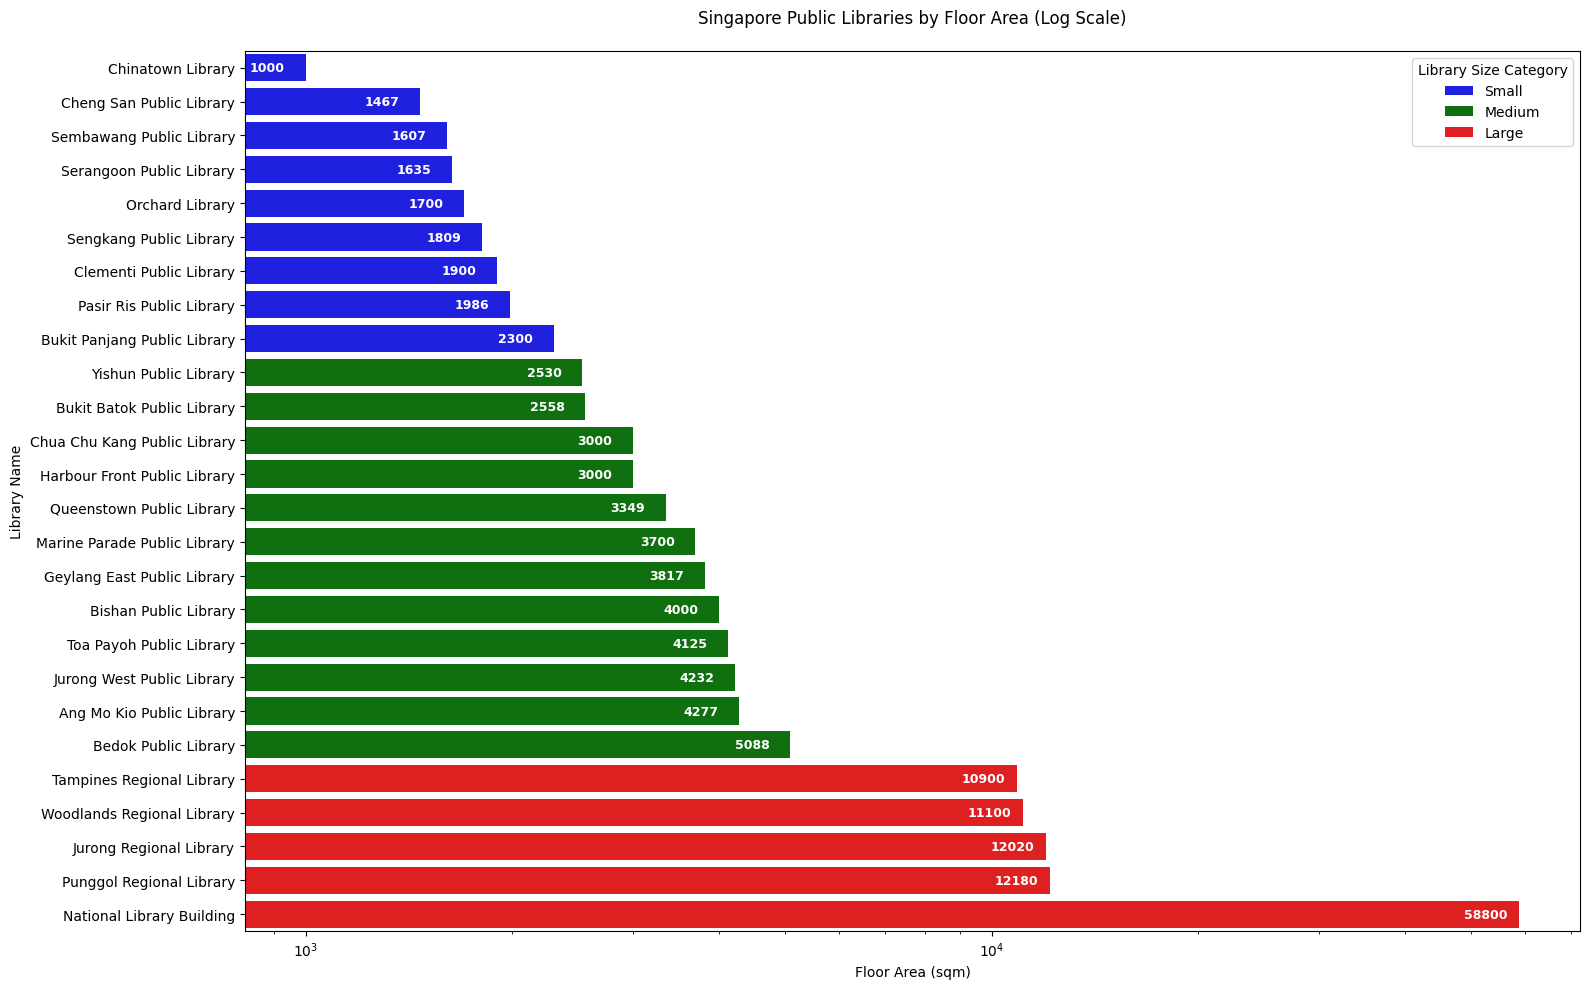

In [ ]:
df_sorted = df_lib_cap_clean.sort_values(by='Floor Area (sqm)', ascending=True)

plt.figure(figsize=(16, 10))
# Create a bar plot to visualize the floor area (sqm) for each public library in ascending order
plot = sns.barplot( data=df_sorted, y ='Library Name', x='Floor Area (sqm)', hue='Category', palette={'Small':'blue','Medium': 'green', 'Large': 'red'}, dodge= False)
# Use a log scale for the Y-axis for better comparison
plt.xscale('log')

plt.legend(title='Library Size Category', loc='best', frameon= True)
# Add numbers inside the bars for better readability
for container in plot.containers:
    plot.bar_label(container, fmt='%.0f', padding=-40, color='white', fontsize=9, weight='bold')

plt.xlabel('Floor Area (sqm)')
plt.ylabel('Library Name')
plt.title('Singapore Public Libraries by Floor Area (Log Scale)', pad=20)


plt.tight_layout()
plt.show()

**Moving away from Small, Medium, Large Categories**


From the bar chart above, we realised that our size categories masked significant variances within each group.
- The Large Category ranged from Tampines Regional Library (10900 sqm) to National Library (58800 sqm)
- The Small Category ranged from Chinatown Public library (1000 sqm) to Bukit Panjang Public Library (2300 sqm)
- Variance between Small and Medium Categories is small compared to variance within Small and Large Categories respectively.

Therefore, moving forward with our data preparation, we will keep the actual floor area and use it to calulate supply-per-capita ratio for each region. This is to ensure higher granularity.

**Exploration steps for DS10**

In [ ]:
df_lib_cap_clean = df_lib_cap_clean.rename(columns={'Library Name': 'Library_Name'})
# Perform the inner join on 'Library_Name' column
df_all_studentsd = pd.merge(df_newlibraries, df_lib_cap_clean, on='Library_Name', how='left')

# Print the merged dataframe
print(df_all_studentsd)

                    Library_Name                Street_Address Postal_Code  \
0       Serangoon Public Library             Serangoon Central      556083   
1                library@orchard                  Orchard Road      238858   
2    Geylang East Public Library            Geylang East Ave 1      389777   
3     Jurong West Public Library         Jurong West Central 3      648346   
4     Bukit Batok Public Library      Bukit Batok Central Link      658713   
5        Sengkang Public Library               Sengkang Square      545078   
6   Marine Parade Public Library            Marine Parade Road      449282   
7       Pasir Ris Public Library        Pasir Ris Central St 3      518457   
8              library@chinatown             North Bridge Road       59413   
9              library@esplanade                Raffles Avenue       39802   
10  Chua Chu Kang Public Library        Choa Chu Kang Avenue 4      689812   
11  Bukit Panjang Public Library                   Jelebu Road  

Upon exploring this data, we note that there are 27 rows that matches our library dataset (DS1), thus the completeness of this dataset is adequate for our task.

We see that during data preparation, the integration of the datasets will require data cleaning techniques due to the ambiguity of the library names in the dataset.
- Different granularity e.g Central library is located in the National library building.
- Different naming conventions e.g library@orchard vs Orchard library,
- Library that is permanently closed e.g library@esplanade

We may need to deal with the synonymous representations of libraries in the Prepare stage to maximise number of joined rows for our analysis.


  
**Quality of Data:**  
Positive:
- The generated data was the best option available that is made available to the public. Unlike a generic municipal data, this curation focused on usable library floor area, serving as a benchmark for the actual library capacity. This is applicable and relevant for our analysis.  
- The interpretability of the dataset is high, given that there is only a few essential attributes with clear semantics which makes misinterpretation and misuse during analysis highly unlikely.

  
Negative:
- Floor area is only a “proxy” for capacity, and it does not take into account functional space. A large library with many bookshelves but very few study tables may have less student capacity than a medium library designed as a “Study Hub”.

- Also, since this is curated by ourselves, it may be prone to manual error or outdated information.  

**Conclusion for DS10**

Overall, this supplementary dataset serves as a necessary analytical bridge, allowing us to have the granularity required for a sophisticated correlation. This is a necessary dataset which allows us to test our hypotheses. While there are a few data quality issues that may affect our analysis, they can be addressed during data preparation through disambiguation and standardization of library names and correct integration of datasets.


# Data preparation (Process)


### Overview

The data preparation phase follows a structured multi-path pipeline to integrate library supply with residential student demand. The process begins with DS1 (Library Locations), where regex is employed to extract metadata from HTML descriptions, followed by padding postal codes for consistency. This is then enriched with DS10 (Library Capacity) via an SQL Outer Join to incorporate floor area metrics. Simultaneously, the Master Plan Boundaries (DS2, DS3, DS4) undergo spatial processing, including re-mapping subzones to planning areas via centroid tracing and spatial joins to account for boundary changes over time. On the demand side, student census data from 2000 to 2020 (DS6, DS7, DS8, DS9) is integrated through attribute joins, with non-residential areas filtered out to ensure data quality. The final stage synthesizes these paths through a spatial join, resulting in a comprehensive dataset that pairs projected 2030 student populations with corresponding library service capacities per planning area.

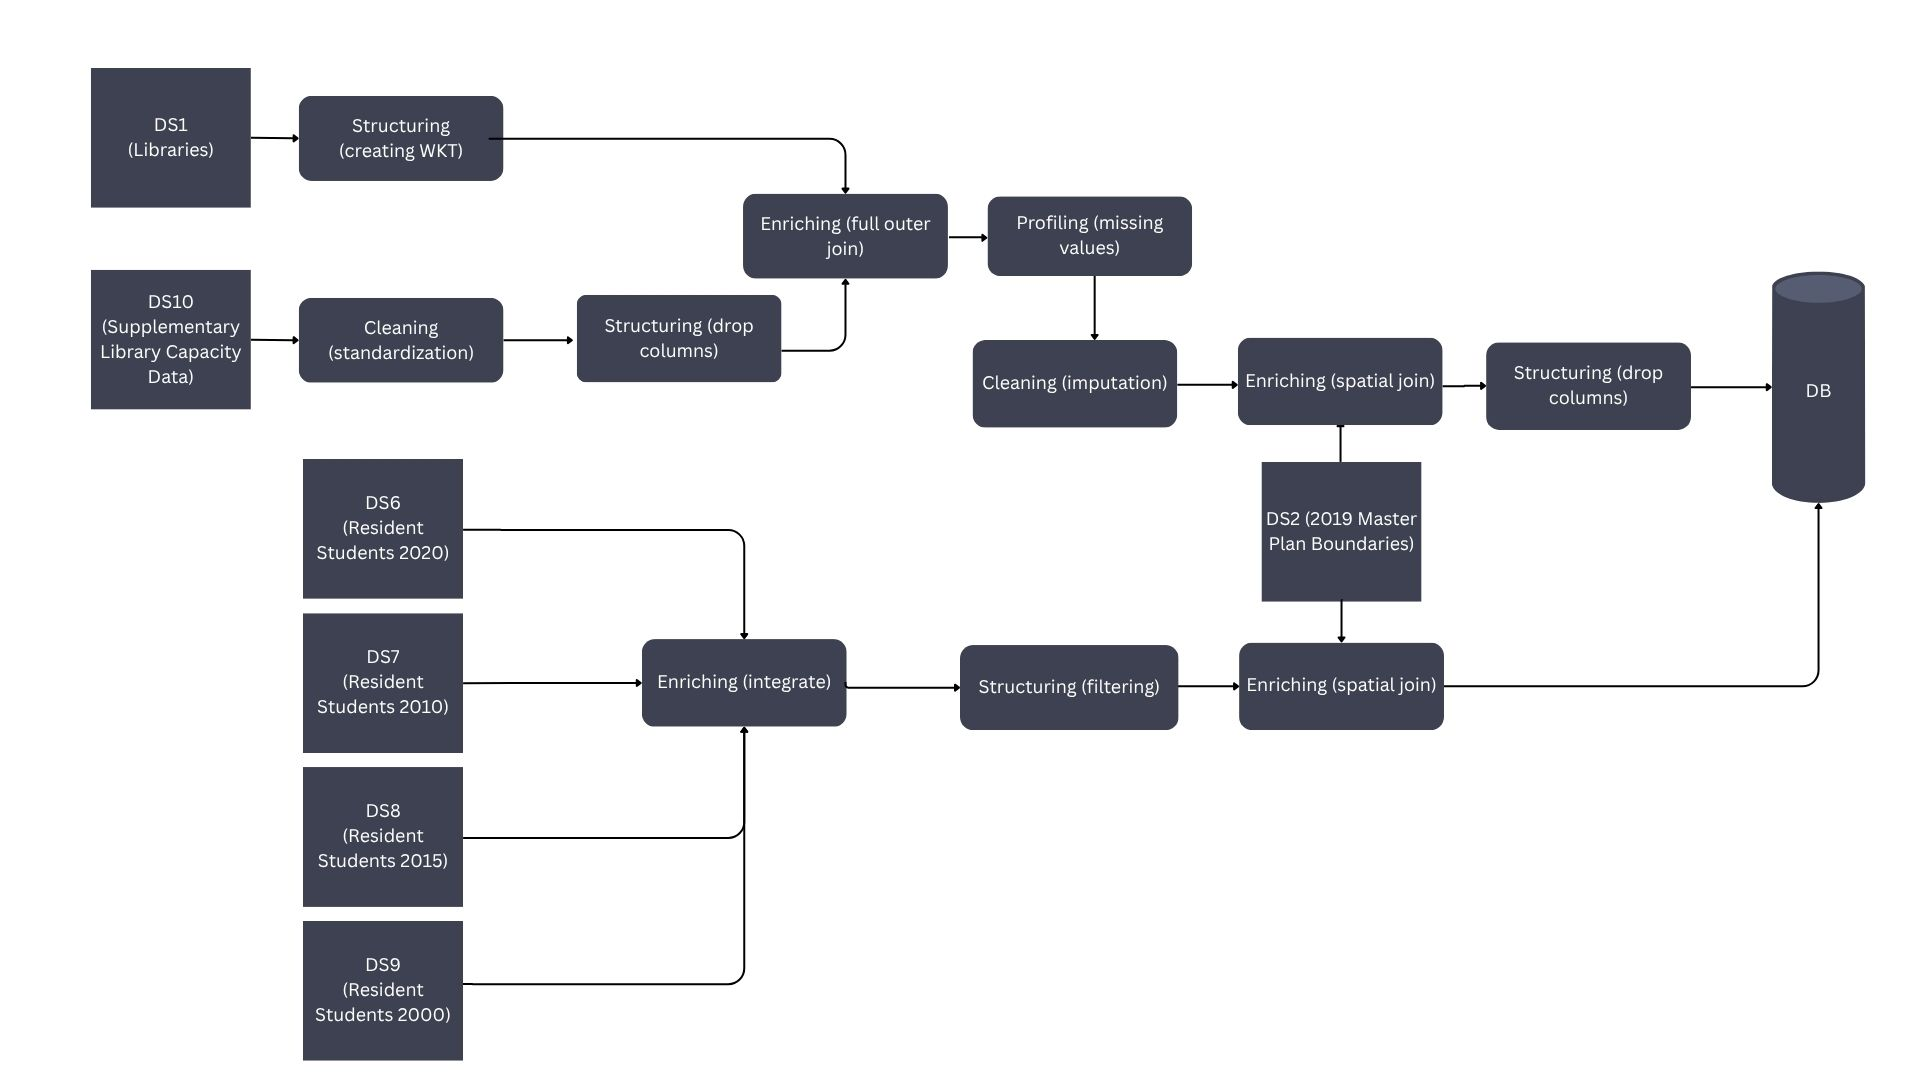

In [ ]:
# Establish connection and create new SQL
conn = sqlite3.connect('library_data.db')

## Structuring DS1


We first ensure all postal codes are of correct format by padding values with leading zeroes. This will help to ensure data validity.

In [ ]:
# P
df_newlibraries['Postal_Code']= df_newlibraries['Postal_Code'].apply(lambda x: str(x).zfill(6))
print(df_newlibraries.head())

                  Library_Name            Street_Address Postal_Code  \
0     Serangoon Public Library         Serangoon Central      556083   
1              library@orchard              Orchard Road      238858   
2  Geylang East Public Library        Geylang East Ave 1      389777   
3   Jurong West Public Library     Jurong West Central 3      648346   
4   Bukit Batok Public Library  Bukit Batok Central Link      658713   

                        geometry  
0  POINT Z (103.87226 1.35073 0)  
1  POINT Z (103.83967 1.30041 0)  
2  POINT Z (103.88584 1.31744 0)  
3  POINT Z (103.70451 1.34064 0)  
4   POINT Z (103.74929 1.3495 0)  


Since standard SQLite tables do not recognise geographic data types(ie. spatial coordinates), we need to reformat the 'geometry' column in DS1 into plain text string representations, also known as Well-Known Text(WKT). This will allow us to load DS1 into SQL for further enriching.

In [ ]:
# Convert DS1 geometry to WKT
df_newlibraries['geometry_wkt'] = df_newlibraries['geometry'].apply(lambda x: x.wkt)
# Make new dataframe for sql convertion
df_newlibraries_sql = df_newlibraries.drop(columns=['geometry'])
df_newlibraries_sql['Library_Name'] = df_newlibraries_sql['Library_Name'].str.strip()
print(df_newlibraries_sql)



                    Library_Name                Street_Address Postal_Code  \
0       Serangoon Public Library             Serangoon Central      556083   
1                library@orchard                  Orchard Road      238858   
2    Geylang East Public Library            Geylang East Ave 1      389777   
3     Jurong West Public Library         Jurong West Central 3      648346   
4     Bukit Batok Public Library      Bukit Batok Central Link      658713   
5        Sengkang Public Library               Sengkang Square      545078   
6   Marine Parade Public Library            Marine Parade Road      449282   
7       Pasir Ris Public Library        Pasir Ris Central St 3      518457   
8              library@chinatown             North Bridge Road      059413   
9              library@esplanade                Raffles Avenue      039802   
10  Chua Chu Kang Public Library        Choa Chu Kang Avenue 4      689812   
11  Bukit Panjang Public Library                   Jelebu Road  

## Data cleaning DS10


In [ ]:
# Renaming the appropriate libraries to standardize and match with DS1
df_lib_cap_clean['Library_Name'] = df_lib_cap_clean['Library_Name'].replace('Orchard Library','library@orchard')
df_lib_cap_clean['Library_Name'] = df_lib_cap_clean['Library_Name'].replace('Chinatown Library','library@chinatown')
df_lib_cap_clean['Library_Name'] = df_lib_cap_clean['Library_Name'].str.strip()

print(df_lib_cap_clean)

                    Library_Name  Floor Area (sqm) Category
0        Jurong Regional Library             12020    Large
1      National Library Building             58800    Large
2      Ang Mo Kio Public Library              4277   Medium
3           Bedok Public Library              5088   Medium
4          Bishan Public Library              4000   Medium
5     Bukit Batok Public Library              2558   Medium
6   Bukit Panjang Public Library              2300    Small
7       Cheng San Public Library              1467    Small
8              library@chinatown              1000    Small
9        Clementi Public Library              1900    Small
10  Chua Chu Kang Public Library              3000   Medium
11    Woodlands Regional Library             11100    Large
12     Tampines Regional Library             10900    Large
13   Geylang East Public Library              3817   Medium
14  Harbour Front Public Library              3000   Medium
15    Jurong West Public Library        

## Structuring DS10 by dropping size category column

In [ ]:
# Drop size category column
df_lib_cap_clean = df_lib_cap_clean.drop(columns=['Category'])

print(df_lib_cap_clean)

                    Library_Name  Floor Area (sqm)
0        Jurong Regional Library             12020
1      National Library Building             58800
2      Ang Mo Kio Public Library              4277
3           Bedok Public Library              5088
4          Bishan Public Library              4000
5     Bukit Batok Public Library              2558
6   Bukit Panjang Public Library              2300
7       Cheng San Public Library              1467
8              library@chinatown              1000
9        Clementi Public Library              1900
10  Chua Chu Kang Public Library              3000
11    Woodlands Regional Library             11100
12     Tampines Regional Library             10900
13   Geylang East Public Library              3817
14  Harbour Front Public Library              3000
15    Jurong West Public Library              4232
16  Marine Parade Public Library              3700
17               library@orchard              1700
18      Pasir Ris Public Librar

## Enriching DS1 with DS10

We then enrich our Libraries dataset(DS1) with the Supplementary Library Capacity dataset(DS10) via SQL merging.  We use a full outer join here to ensure we preserve all records from DS1 and DS10, even if there is no matching data.


In [ ]:
# Load dataframes of DS1 and DS10 into SQLite database
df_newlibraries_sql.to_sql('lib', con=conn, if_exists='replace', index=False)
df_lib_cap_clean.to_sql('lib_capacity', con=conn, if_exists='replace', index=False)

26

In [ ]:
# Simulating a FULL OUTER JOIN in SQLite using UNION of two LEFT JOINs
query = """
SELECT
    COALESCE(l.Library_Name, c.Library_Name) AS Library_Name,
    l.Street_Address,
    l.Postal_Code,
    l.geometry_wkt,
    c."Floor Area (sqm)"
FROM lib AS l
LEFT JOIN lib_capacity AS c
    ON l.Library_Name = c.Library_Name

UNION

SELECT
    COALESCE(l.Library_Name, c.Library_Name) AS Library_Name,
    l.Street_Address,
    l.Postal_Code,
    l.geometry_wkt,
    c."Floor Area (sqm)"
FROM lib_capacity AS c
LEFT JOIN lib AS l
    ON l.Library_Name = c.Library_Name
"""

df_enriched = pd.read_sql_query(query, conn)
print(df_enriched.to_string())

                    Library_Name                Street_Address Postal_Code                                   geometry_wkt  Floor Area (sqm)
0      Ang Mo Kio Public Library           Ang Mo Kio Avenue 6      569842  POINT Z (103.845580674824 1.37479006912036 0)            4277.0
1           Bedok Public Library             Bedok North St. 1      469662  POINT Z (103.931691125839 1.32698939805286 0)            5088.0
2          Bishan Public Library                  Bishan Place      579841   POINT Z (103.848840445413 1.3498506667736 0)            4000.0
3     Bukit Batok Public Library      Bukit Batok Central Link      658713  POINT Z (103.749285191724 1.34949754800173 0)            2558.0
4   Bukit Panjang Public Library                   Jelebu Road      677743  POINT Z (103.764350064878 1.37993637366735 0)            2300.0
5         Central Public Library  Victoria Street (Basement 1)      188064   POINT Z (103.854234798536 1.2974201806193 0)               NaN
6       Cheng San Pu

## Profiling missing values in enriched DS1 dataset

Some library records have missing floor area values because of three main reasons:

- **Naming Discrepancies**: During the join process, if the Library_Name in the geographical dataset (DS1) doesn't exactly match the name in the supplementary capacity dataset (DS10), the data won't link. For example, 'Central Public Library' might be missing because it is nested within the 'National Library Building' record in one of the datasets
- **Dataset Completeness**: The supplementary dataset (DS10) was manually curated to bridge gaps in official data. It's possible that some newer libraries or specific branches weren't included in that initial CSV.
- **Recent Closures or Changes**: As noted in the profiling, some branches like library@esplanade have permanently closed, meaning they might exist in geographical historical records but lack current capacity data.

In [ ]:
# Summary of missingness
print("Missing Value Count:")
print(df_enriched.isnull().sum())

# Identify the specific 'problem' records
missing_mask = df_enriched.isnull().any(axis=1)
missing_records = df_enriched[missing_mask]

print("\nRecords needing attention:")
print(missing_records[['Library_Name', 'Street_Address', 'Floor Area (sqm)']])

Missing Value Count:
Library_Name        0
Street_Address      1
Postal_Code         1
geometry_wkt        1
Floor Area (sqm)    2
dtype: int64

Records needing attention:
                Library_Name                Street_Address  Floor Area (sqm)
5     Central Public Library  Victoria Street (Basement 1)               NaN
16  Punggol Regional Library                          None           12180.0
26         library@esplanade                Raffles Avenue               NaN


## Data cleaning through data imputation



We find the missing values from official sources (NLB) and apply them
-  Central Public Library (floor area): 4131 sqm
- the library@esplanade permanently closed in 2023 (We will remove this record from the database)
- Punggol Regional Library (address): 1 Punggol Drive, One Punggol, #01-12, 828629

We also found coordinates(latitude and longitude) for Punggol Regional Library using [Google Maps](https://maps.app.goo.gl/RN2PMLTrysd2HkEb7)


In [ ]:
# Filling specific missing values
df_enriched.loc[df_enriched['Library_Name'] == 'Central Public Library', ['Floor Area (sqm)']] = [4131]
# Remove the library@esplanade record
df_enriched = df_enriched[df_enriched['Library_Name'] != 'library@esplanade']
# Update address for Punggol Regional Library
df_enriched.loc[df_enriched['Library_Name'] == 'Punggol Regional Library', 'Street_Address'] = '1 Punggol Drive'
df_enriched.loc[df_enriched['Library_Name'] == 'Punggol Regional Library', 'Postal_Code'] = '828629'

# Update geometry for Punggol Regional Library
df_enriched.loc[df_enriched['Library_Name'] == 'Punggol Regional Library', 'geometry_wkt'] = 'POINT Z (103.905083 1.408936 0)'

print(df_enriched)

                    Library_Name                Street_Address Postal_Code  \
0      Ang Mo Kio Public Library           Ang Mo Kio Avenue 6      569842   
1           Bedok Public Library             Bedok North St. 1      469662   
2          Bishan Public Library                  Bishan Place      579841   
3     Bukit Batok Public Library      Bukit Batok Central Link      658713   
4   Bukit Panjang Public Library                   Jelebu Road      677743   
5         Central Public Library  Victoria Street (Basement 1)      188064   
6       Cheng San Public Library             Hougang Avenue 10      538766   
7   Chua Chu Kang Public Library        Choa Chu Kang Avenue 4      689812   
8        Clementi Public Library      Commonwealth Avenue West      129588   
9    Geylang East Public Library            Geylang East Ave 1      389777   
10  Harbour Front Public Library             Harbourfront Walk      098585   
11       Jurong Regional Library         Jurong East Central 1  

Now that all libraries have a corresponding floor area, we sum them up by Postal Code, merging libraries with the same postal code into one point. We assume that the floor area for larger buildings will be inclusive of smaller nested libraries, hence we take the maximum floor area value for each postal code to prevent double counting.

In [ ]:
# Group by Postal Code to merge library entities in the same location.
df_enriched = df_enriched.groupby('Postal_Code').agg({
    'Library_Name': lambda x: ' & '.join(x),
    'Floor Area (sqm)': 'max', # Use 'max' value between merge libraies
    'Street_Address': 'first',
    'geometry_wkt': 'first'
}).reset_index()


print(df_enriched)

   Postal_Code                                       Library_Name  \
0       059413                                  library@chinatown   
1       098585                       Harbour Front Public Library   
2       129588                            Clementi Public Library   
3       149297                          Queenstown Public Library   
4       188064  Central Public Library & National Library Buil...   
5       238858                                    library@orchard   
6       319191                           Toa Payoh Public Library   
7       389777                        Geylang East Public Library   
8       449282                       Marine Parade Public Library   
9       469662                               Bedok Public Library   
10      518457                           Pasir Ris Public Library   
11      528523                          Tampines Regional Library   
12      538766                           Cheng San Public Library   
13      545078                    

## Enriching Libraries dataset with DS2

In order to perform a spatial join between spatial points in the enriched library dataset and the spatial polygons in the Master Plan Boundaries 2019, we need to convert the WKT strings in the geometry column back to geometric objects.

In [ ]:
# Convert the WKT string column back into a geometry object
df_enriched['geometry'] = df_enriched['geometry_wkt'].apply(shapely.wkt.loads)

# Create GeoDataFrame
gdf_lib = gpd.GeoDataFrame(df_enriched, geometry='geometry',crs="EPSG:4326")
gdf_lib = gdf_lib.drop(columns=['geometry_wkt'])


df_final_lib = gpd.sjoin(gdf_lib, df_planning_area, how='left', predicate='within')

print(df_final_lib.head())

  Postal_Code                                       Library_Name  \
0      059413                                  library@chinatown   
1      098585                       Harbour Front Public Library   
2      129588                            Clementi Public Library   
3      149297                          Queenstown Public Library   
4      188064  Central Public Library & National Library Buil...   

   Floor Area (sqm)                Street_Address  \
0            1000.0             North Bridge Road   
1            3000.0             Harbourfront Walk   
2            1900.0      Commonwealth Avenue West   
3            3349.0                Margaret Drive   
4           58800.0  Victoria Street (Basement 1)   

                        geometry  index_right     PLN_AREA_N        REGION_N  \
0  POINT Z (103.84494 1.28526 0)           45         Outram  Central Region   
1  POINT Z (103.82163 1.26392 0)            3    Bukit Merah  Central Region   
2  POINT Z (103.76431 1.31506 0)

##Structuring final libraries dataset by dropping columns

In [ ]:
# Drop columns that we do not need for data analysis
df_final_lib = df_final_lib.drop(columns=['Street_Address', 'Postal_Code', 'index_right'])
print(df_final_lib.head())

                                        Library_Name  Floor Area (sqm)  \
0                                  library@chinatown            1000.0   
1                       Harbour Front Public Library            3000.0   
2                            Clementi Public Library            1900.0   
3                          Queenstown Public Library            3349.0   
4  Central Public Library & National Library Buil...           58800.0   

                        geometry     PLN_AREA_N        REGION_N  AREA_M_SQM  
0  POINT Z (103.84494 1.28526 0)         Outram  Central Region    1.373186  
1  POINT Z (103.82163 1.26392 0)    Bukit Merah  Central Region   14.461199  
2  POINT Z (103.76431 1.31506 0)       Clementi     West Region    9.521328  
3  POINT Z (103.80552 1.29871 0)     Queenstown  Central Region   21.683971  
4  POINT Z (103.85423 1.29742 0)  Downtown Core  Central Region    5.083637  


## Enriching DS6, DS7, DS8, DS9 through integration

In [ ]:
# Merge DS7 and DS9, linking based on "Planning Area" as the join key attribute
df_all_students = pd.merge(
    df_student2000[['Planning Area', '2000 Resident Students']],
    df_student2010[['Planning Area', '2010 Resident Students']],
    on='Planning Area',
    how='outer'
)

# Merge DS8 and the integrated dataset, linking based on "Planning Area" as the join key attribute
df_all_students = pd.merge(
    df_all_students,
    df_student2015[['Planning Area', '2015 Resident Students']],
    on='Planning Area',
    how='outer'
)

# Merge DS6 and the integrated dataset, linking based on "Planning Area" as the join key attribute
df_all_students = pd.merge(
    df_all_students,
    df_student2020[['Planning Area', '2020 Resident Students']],
    on='Planning Area',
    how='outer'
)

print(df_all_students)

      Planning Area  2000 Resident Students  2010 Resident Students  \
0        Ang Mo Kio                 35570.0                   31023   
1             Bedok                 58181.0                   57802   
2            Bishan                 21328.0                   20922   
3       Bukit Batok                 31402.0                   33277   
4       Bukit Merah                 22810.0                   23013   
5     Bukit Panjang                 24271.0                   31421   
6       Bukit Timah                 14694.0                   15893   
7            Changi                   181.0                     529   
8     Choa Chu Kang                 35517.0                   46661   
9          Clementi                 17132.0                   15674   
10    Downtown Core                   586.0                     449   
11          Geylang                 22779.0                   21532   
12          Hougang                 49915.0                   48174   
13    

In [ ]:
# Check for nulls
df_all_students.isna().sum()

,0
Planning Area,0
2000 Resident Students,3
2010 Resident Students,0
2015 Resident Students,7
2020 Resident Students,5


The exploration shows that every planning area in the merged dataset has a corresponding value in the 2010 data. However, there are 4 null values in 2000, 8 in 2015, and 6 in 2020, indicating that several Planning Areas either did not exist or had no recorded residential population during those periods.

This could suggests a transition toward non-residential land use. For Areas, that has less than 2 data points required for a 2030 linear projection, they will be excluded from the chloropleth map in the Analysis stage.


In [ ]:
# Fill Null Values with 0
df_all_students.fillna(0, inplace=True)

# Convert student counts to integers for cleaner analysis
df_all_students[['2000 Resident Students', '2010 Resident Students', '2015 Resident Students', '2020 Resident Students']] = df_all_students[['2000 Resident Students', '2010 Resident Students', '2015 Resident Students', '2020 Resident Students']].astype(int)

print(df_all_students)

      Planning Area  2000 Resident Students  2010 Resident Students  \
0        Ang Mo Kio                   35570                   31023   
1             Bedok                   58181                   57802   
2            Bishan                   21328                   20922   
3       Bukit Batok                   31402                   33277   
4       Bukit Merah                   22810                   23013   
5     Bukit Panjang                   24271                   31421   
6       Bukit Timah                   14694                   15893   
7            Changi                     181                     529   
8     Choa Chu Kang                   35517                   46661   
9          Clementi                   17132                   15674   
10    Downtown Core                     586                     449   
11          Geylang                   22779                   21532   
12          Hougang                   49915                   48174   
13    

In [ ]:
df_all_students = df_all_students.sort_values(by='2020 Resident Students', ascending=False)

# Melt the dataframe
df_comparison = df_all_students.melt(id_vars='Planning Area',
                       value_vars=['2010 Resident Students', '2020 Resident Students'],
                       var_name='Census Year',
                       value_name='Student Count')

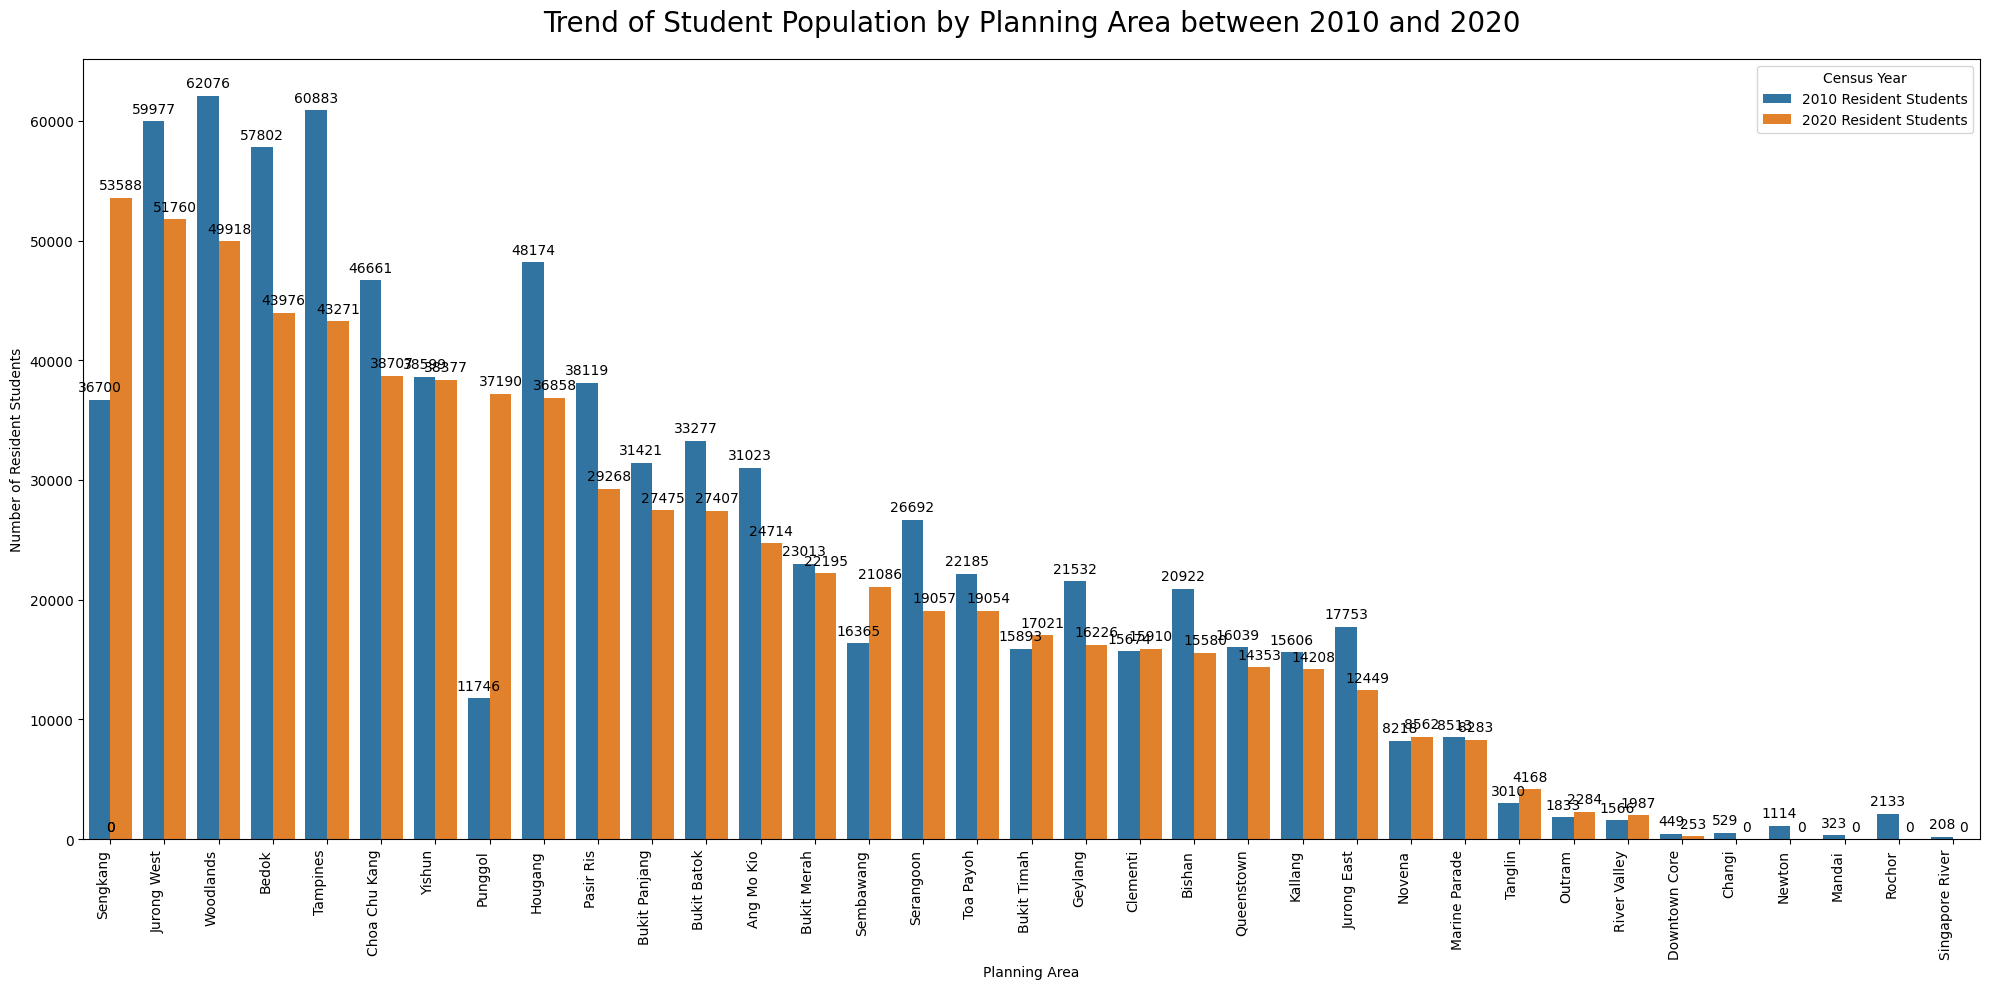

In [ ]:
plt.figure(figsize=(20, 10))

plot = sns.barplot(data=df_comparison, x='Planning Area', y='Student Count', hue='Census Year')
plt.legend(title='Census Year', loc='upper right')

plt.title('Trend of Student Population by Planning Area between 2010 and 2020', pad=20, fontsize=20)
plt.xlabel('Planning Area')
plt.ylabel('Number of Resident Students')
plt.xticks(rotation=90, ha='right')

# Adding numbers on top of the bars for better readability
for p in plot.patches:
    plot.annotate(format(p.get_height(), '.0f'), # Express values as whole numbers
                   (p.get_x() + p.get_width() / 2., p.get_height()), # Set the x- and y-coordinates for the annotation
                   ha = 'center', va = 'center',  # Centralize the value
                   xytext = (0, 9),
                   textcoords = 'offset points')

plt.tight_layout()
plt.show()

In [ ]:
# Calculate changes in population
df_all_students['Population Change'] = df_all_students['2020 Resident Students'] - df_all_students['2010 Resident Students']

# Calculate percentage growth
df_all_students['Percentage Growth'] = (df_all_students['Population Change'] / df_all_students['2010 Resident Students']) * 100

# Round specific columns to 3 decimal places
df_all_students['Percentage Growth'] = df_all_students['Percentage Growth'].round(3)

# Sort by Population Change in descending order
df_all_students = df_all_students.sort_values(by='Population Change', ascending=False)

print(df_all_students[['Planning Area', '2000 Resident Students', '2010 Resident Students', '2015 Resident Students', '2020 Resident Students',
                'Population Change', 'Percentage Growth']].to_string(index=False))

  Planning Area  2000 Resident Students  2010 Resident Students  2015 Resident Students  2020 Resident Students  Population Change  Percentage Growth
        Punggol                       0                   11746                   19700                   37190              25444            216.618
       Sengkang                   11714                   36700                   49700                   53588              16888             46.016
      Sembawang                    5690                   16365                   18000                   21086               4721             28.848
        Tanglin                    2454                    3010                    3500                    4168               1158             38.472
    Bukit Timah                   14694                   15893                   15700                   17021               1128              7.097
         Outram                    2846                    1833                    2800             

In [ ]:
# Perform record-based filtering to remove planning areas where residential student population <= 0
df_all_students = df_all_students[df_all_students['2020 Resident Students'] > 0]
print(df_all_students)

    Planning Area  2000 Resident Students  2010 Resident Students  \
22        Punggol                       0                   11746   
27       Sengkang                   11714                   36700   
26      Sembawang                    5690                   16365   
31        Tanglin                    2454                    3010   
6     Bukit Timah                   14694                   15893   
20         Outram                    2846                    1833   
24   River Valley                    1440                    1566   
19         Novena                    7895                    8218   
9        Clementi                   17132                   15674   
10  Downtown Core                     586                     449   
34         Yishun                   43726                   38599   
17  Marine Parade                    7936                    8513   
4     Bukit Merah                   22810                   23013   
15        Kallang                 

## Structuring integrated dataset via filtering

We perform data filtering to exclude planning areas that reported a resident student population of zero in 2020. In instances where a planning area reports zero residents, it functions as a non-residential within the scope of this study. By removing these entries with 0 values, we account for modern land-use changes, hence, filtering the dataset to reflect active residential zones.

In [ ]:
df_all_students = df_all_students[df_all_students['2020 Resident Students'] > 0]
print(df_all_students[['Planning Area', '2000 Resident Students', '2010 Resident Students', '2015 Resident Students', '2020 Resident Students']].to_string(index=False))

Planning Area  2000 Resident Students  2010 Resident Students  2015 Resident Students  2020 Resident Students
      Punggol                       0                   11746                   19700                   37190
     Sengkang                   11714                   36700                   49700                   53588
    Sembawang                    5690                   16365                   18000                   21086
      Tanglin                    2454                    3010                    3500                    4168
  Bukit Timah                   14694                   15893                   15700                   17021
       Outram                    2846                    1833                    2800                    2284
 River Valley                    1440                    1566                       0                    1987
       Novena                    7895                    8218                    7900                    8562
     Cleme

## Further enriching student population dataset using DS2


We enrich the filtered student census data using the 2019 Master Plan Planning Area boundaries(DS2) via an attribute join. This ensures that only active residential zones are carried forward in the analysis, allowing us to visualise student demand for libraries spatially.

In [ ]:
gdf_student_demand = df_planning_area.merge(
    df_all_students,
    left_on='PLN_AREA_N',
    right_on='Planning Area',
    how='inner'
)
print(gdf_student_demand)

       PLN_AREA_N           REGION_N  \
0           Bedok        East Region   
1     Bukit Batok        West Region   
2     Bukit Merah     Central Region   
3   Bukit Panjang        West Region   
4     Bukit Timah     Central Region   
5   Choa Chu Kang        West Region   
6        Clementi        West Region   
7         Hougang  North-East Region   
8     Jurong East        West Region   
9     Jurong West        West Region   
10      Pasir Ris        East Region   
11        Punggol  North-East Region   
12     Queenstown     Central Region   
13      Sembawang       North Region   
14       Sengkang  North-East Region   
15      Serangoon  North-East Region   
16        Kallang     Central Region   
17         Novena     Central Region   
18      Toa Payoh     Central Region   
19      Woodlands       North Region   
20   River Valley     Central Region   
21  Marine Parade     Central Region   
22  Downtown Core     Central Region   
23         Outram     Central Region   


In [ ]:
# Drop duplicate columns and rename columns for better readability
gdf_student_demand = gdf_student_demand.drop(columns=['Planning Area'])
gdf_student_demand = gdf_student_demand.rename(columns={'PLN_AREA_N': 'Planning Area', 'REGION_N':'Region'})


print(gdf_student_demand)

    Planning Area             Region  \
0           Bedok        East Region   
1     Bukit Batok        West Region   
2     Bukit Merah     Central Region   
3   Bukit Panjang        West Region   
4     Bukit Timah     Central Region   
5   Choa Chu Kang        West Region   
6        Clementi        West Region   
7         Hougang  North-East Region   
8     Jurong East        West Region   
9     Jurong West        West Region   
10      Pasir Ris        East Region   
11        Punggol  North-East Region   
12     Queenstown     Central Region   
13      Sembawang       North Region   
14       Sengkang  North-East Region   
15      Serangoon  North-East Region   
16        Kallang     Central Region   
17         Novena     Central Region   
18      Toa Payoh     Central Region   
19      Woodlands       North Region   
20   River Valley     Central Region   
21  Marine Parade     Central Region   
22  Downtown Core     Central Region   
23         Outram     Central Region   


# Data Analysis (Analyze)


> *Clearly state which type of analysis you conduct (descriptive, diagnostic, predictive, prescriptive) and the methods you use (e.g., time series decomposition, root cause analysis, etc.). Your project should include at least one analysis. When conducting several analysis techniques / methods, specify each of them.*



Given that our overarching goal is to identify future demand for library spaces and geographical shifts in the student population, we apply the following methods:

**Predictive Analytics:** Quadratic Polynomial Regression modeling to project 2030 student populations.

**Descriptive Analytics:** Geospatial Mapping (Choropleth map) to visualize geographic demand distribution.

**Descriptive Analytics:** Calculating library supply-per-capita ratio per region

## Projection of student population in 2030 (predictive analysis)

**Goal:** The goal is to estimate the resident student population for the year 2030 across all Planning Areas based on patterns in existing data from 2000 to 2020.

**Methods / measures:** We implement a Quadratic Polynomial Regression model for each planning area. The census years serve as the independent variable (X), and the resident student population serve as the dependent variable (Y). To assess the reliability of these projections, we calculate the Coefficient of Determination (R^2 value), where a value closer to 1.0 indicates a highly predictable population trend.

**Code:** For each planning area, we fit the polynomial regression that models the relationship with a quadratic function to existing data.

In [ ]:
# Create a copy of df_all_students
df_master = df_all_students.copy()

# Determine the sequence of columns
print(df_master.columns.tolist())

['Planning Area', '2000 Resident Students', '2010 Resident Students', '2015 Resident Students', '2020 Resident Students', 'Population Change', 'Percentage Growth']


In [ ]:
def regressionModel(row):
    """
    Performs a quadratic regression on historical student data to project the student population in 2030 for each planning area.

    Arg:
    ----
      row(pd.Series): A row from a DataFrame containing Resident Students Population data in 2000, 2010, 2015, and 2020.

    Returns:
    ----
      pd.Series: A Series containing [2030_prediction (int), r2_score (float)] or [NaN, NaN] if insufficient data.
    """

    # Fetch data
    years = np.array([2000, 2010, 2015, 2020])
    data_points = [row.get(f'{y} Resident Students', np.nan) for y in years]
    counts = np.array(data_points, dtype=float)

    # DROPPING ZEROS AND NANS
    # A student population of exactly 0 in a residential area is likely a data error
    mask = (~np.isnan(counts)) & (counts > 0)

    # Check if we still have at least 3 valid points to make a curve
    if sum(mask) < 3:
        # However, if there are only 2 points, we can't do a curve, return NaN or a linear fit
        return pd.Series([np.nan, np.nan])

    X_train, y_train = years[mask], counts[mask]

    try:
        # Fit Polynomial Regression Model to existing data
        weights = np.polyfit(X_train, y_train, 2)
        model = np.poly1d(weights)

        # Calculate R2
        y_pred = model(X_train)
        r2 = r2_score(y_train, y_pred)

        # Calculate 2030 Population Projection
        prediction = int(round(max(0, model(2030))))

        return pd.Series([prediction, r2])
    except:
        return pd.Series([np.nan, np.nan])

# Apply the updated logic
df_master[['2030 Projected Students', 'R2 Value']] = df_master.apply(regressionModel, axis=1)

In [ ]:
print(df_master)

    Planning Area  2000 Resident Students  2010 Resident Students  \
22        Punggol                       0                   11746   
27       Sengkang                   11714                   36700   
26      Sembawang                    5690                   16365   
31        Tanglin                    2454                    3010   
6     Bukit Timah                   14694                   15893   
20         Outram                    2846                    1833   
24   River Valley                    1440                    1566   
19         Novena                    7895                    8218   
9        Clementi                   17132                   15674   
10  Downtown Core                     586                     449   
34         Yishun                   43726                   38599   
17  Marine Parade                    7936                    8513   
4     Bukit Merah                   22810                   23013   
15        Kallang                 

Required info | Your answer
-------------------|------------------
GenAI tool name | Gemini
Input prompt |  Implement the code for regression models that models a relationship with a polynomial function and linear function for comparison. Then, for the corresponding model, show the graph.
Generated output |see comment below
Impacted notebook cell | Projection of student population in 2030 (predictive analysis) - code cell 3

In [ ]:
# prompt: Implement the code for regression models that models a relationship with a polynomial function and linear function for comparison. Then, for each model, show the graph.

### def plot_regression(degree):
###    plt.figure(figsize=(10, 6))
###    plt.scatter(X, y, color='gray', alpha=0.5, label='Actual Data')

###    # --- Linear Model ---
###    lin_reg = LinearRegression()
###    lin_reg.fit(X, y)
###    X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
###    y_lin_pred = lin_reg.predict(X_plot)
###    plt.plot(X_plot, y_lin_pred, color='red', linestyle='--', label='Linear Model')

###    # --- Polynomial Model ---
###    poly_features = PolynomialFeatures(degree=degree)
###    X_poly = poly_features.fit_transform(X)
###    X_plot_poly = poly_features.transform(X_plot)

###    poly_reg = LinearRegression()
###    poly_reg.fit(X_poly, y)
###    y_poly_pred = poly_reg.predict(X_plot_poly)

###    plt.plot(X_plot, y_poly_pred, color='blue', linewidth=2, label=f'Polynomial Model (Degree {degree})')

###    plt.title(f'Comparison: Linear vs Polynomial Regression (Degree {degree})')
###    plt.xlabel('X')
###    plt.ylabel('y')
###    plt.legend()
###    plt.grid(True, alpha=0.3)
###    plt.show()

### # 2. Create Interactive Widget
### degree_slider = widgets.IntSlider(
###    value=2,
###    min=1,
###    max=10,
###    step=1,
###    description='Poly Degree:',
###    continuous_update=False
### )

### widgets.interact(plot_regression, degree=degree_slider);

def visualize_regression(selected_area):
    """
    Prints a Matplotlib visualization comparing historical census data with
    quadratic and linear regression models for each planning area.

    Arg:
    ----
      selected_area(str): The name of the planning area to filter from df_master.

    Returns:
    ----
      None: Displays an interactive plot using plt.show().
    """

    # Return only one specific row
    subset = df_master[df_master['Planning Area'] == selected_area].squeeze()

    years = np.array([2000, 2010, 2015, 2020])
    counts = np.array([subset.get(f'{y} Resident Students', np.nan) for y in years], dtype=float)

    # Drop Null values and 0s so they don't influence the plot
    mask = (~np.isnan(counts)) & (counts > 0)
    X_train, y_train = years[mask], counts[mask]

    plt.figure(figsize=(12, 6))

    # Plotting valid dots only
    plt.scatter(X_train, y_train, color='black', marker=".", s=100, label='Historical Census Data', zorder=3)

    proj_2030 = subset.get('2030 Projected Students')

    if pd.notnull(proj_2030) and len(X_train) >= 2:
        # Fit Quadratic Curve to the data
        curve_x = np.linspace(2000, 2030, 100)
        weights = np.polyfit(X_train, y_train, 2)
        model_poly = np.poly1d(weights)
        plt.plot(curve_x, model_poly(curve_x), color='red', linestyle=':', linewidth=2, label='Polynomial Forecast Path')

        # Fit Linear Regression to the data
        model_lin = LinearRegression()
        model_lin.fit(X_train.reshape(-1, 1), y_train)
        plt.plot([2000, 2030], model_lin.predict([[2000], [2030]]), color='gray', linestyle='--', alpha=0.5, label='Linear Trendline')

        # 2030 Marker
        plt.scatter([2030], [proj_2030], color='red', marker='x', s=200, zorder=4,
                    label=f'2030 Projected: {int(proj_2030)}')

    plt.title(f'Population Projection: {selected_area} (Quadratic Model)', fontsize=16, fontweight='bold')
    plt.xlabel('Year')
    plt.ylabel('Resident Students')
    plt.xticks([2000, 2010, 2015, 2020, 2030])
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    plt.ylim(bottom=0)
    plt.legend(frameon=True, loc='lower right')
    plt.show()

# Re-display widget
area_selector = widgets.Dropdown(options=sorted(df_master['Planning Area'].unique()), description='Planning Area:')
widgets.interactive(visualize_regression, selected_area=area_selector)

interactive(children=(Dropdown(description='Planning Area:', options=('Ang Mo Kio', 'Bedok', 'Bishan', 'Bukit …

In [ ]:
# Select and format the projection columns
df_projection_2030 = df_master[['Planning Area', '2020 Resident Students', '2030 Projected Students', 'R2 Value']].copy()

# Sort by R2 Value
df_projection_2030 = df_projection_2030.sort_values(by='R2 Value', ascending=False)

print("Singapore 2030 Student Population Projections")
display(df_projection_2030.reset_index(drop="True" ))

Singapore 2030 Student Population Projections


,Planning Area,2020 Resident Students,2030 Projected Students,R2 Value
0,Punggol,37190,100778.0,1.000000
1,River Valley,1987,2703.0,1.000000
2,Downtown Core,253,0.0,1.000000
3,Tanglin,4168,5938.0,0.999931
4,Hougang,36858,16049.0,0.999927
5,Bukit Panjang,27475,12386.0,0.999926
6,Jurong East,12449,5242.0,0.998992
7,Sengkang,53588,59801.0,0.993187
8,Tampines,43271,10399.0,0.993185
9,Kallang,14208,11421.0,0.992871


**Interpretation:**
- Areas like Punggol and Sengkang show sharp upward quadratic curves with very high student counts. These represent 'high-pressure' zones where current library floor area is likely already stretched and will face significant deficit by 2030.
- Large residential areas like Bedok, Tampines, and Jurong West tend to show high R² values but flatter curves. This indicates a 'stable' demand. For these areas, the focus should be on optimizing existing spaces rather than building entirely new infrastructure.
- Certain central areas like Downtown Core or maturing estates may show a downward trend. A declining projection here suggests that library resources could potentially be shifted or specialized towards other demographics, such as working professionals or senior citizens, rather than student study spaces.


**Limitations:** A significant constraint of this study is the limited sample size, as the model relies on at most four historical census data points (2000, 2010, 2015, or/and 2020). This increases the risk of overfitting, where the quadratic curve may track minor historical fluctuations rather than long-term demographic shifts.

## Visualize geographic demand distribution (descriptive analysis)

**Goal:** The goal is to visually describe the student population data for the different planning areas

**Methods:** Geospatial visualization using choropleth map

**Code:** The following code colored the planning areas with > 0 students and use grey to represent the non-residential areas

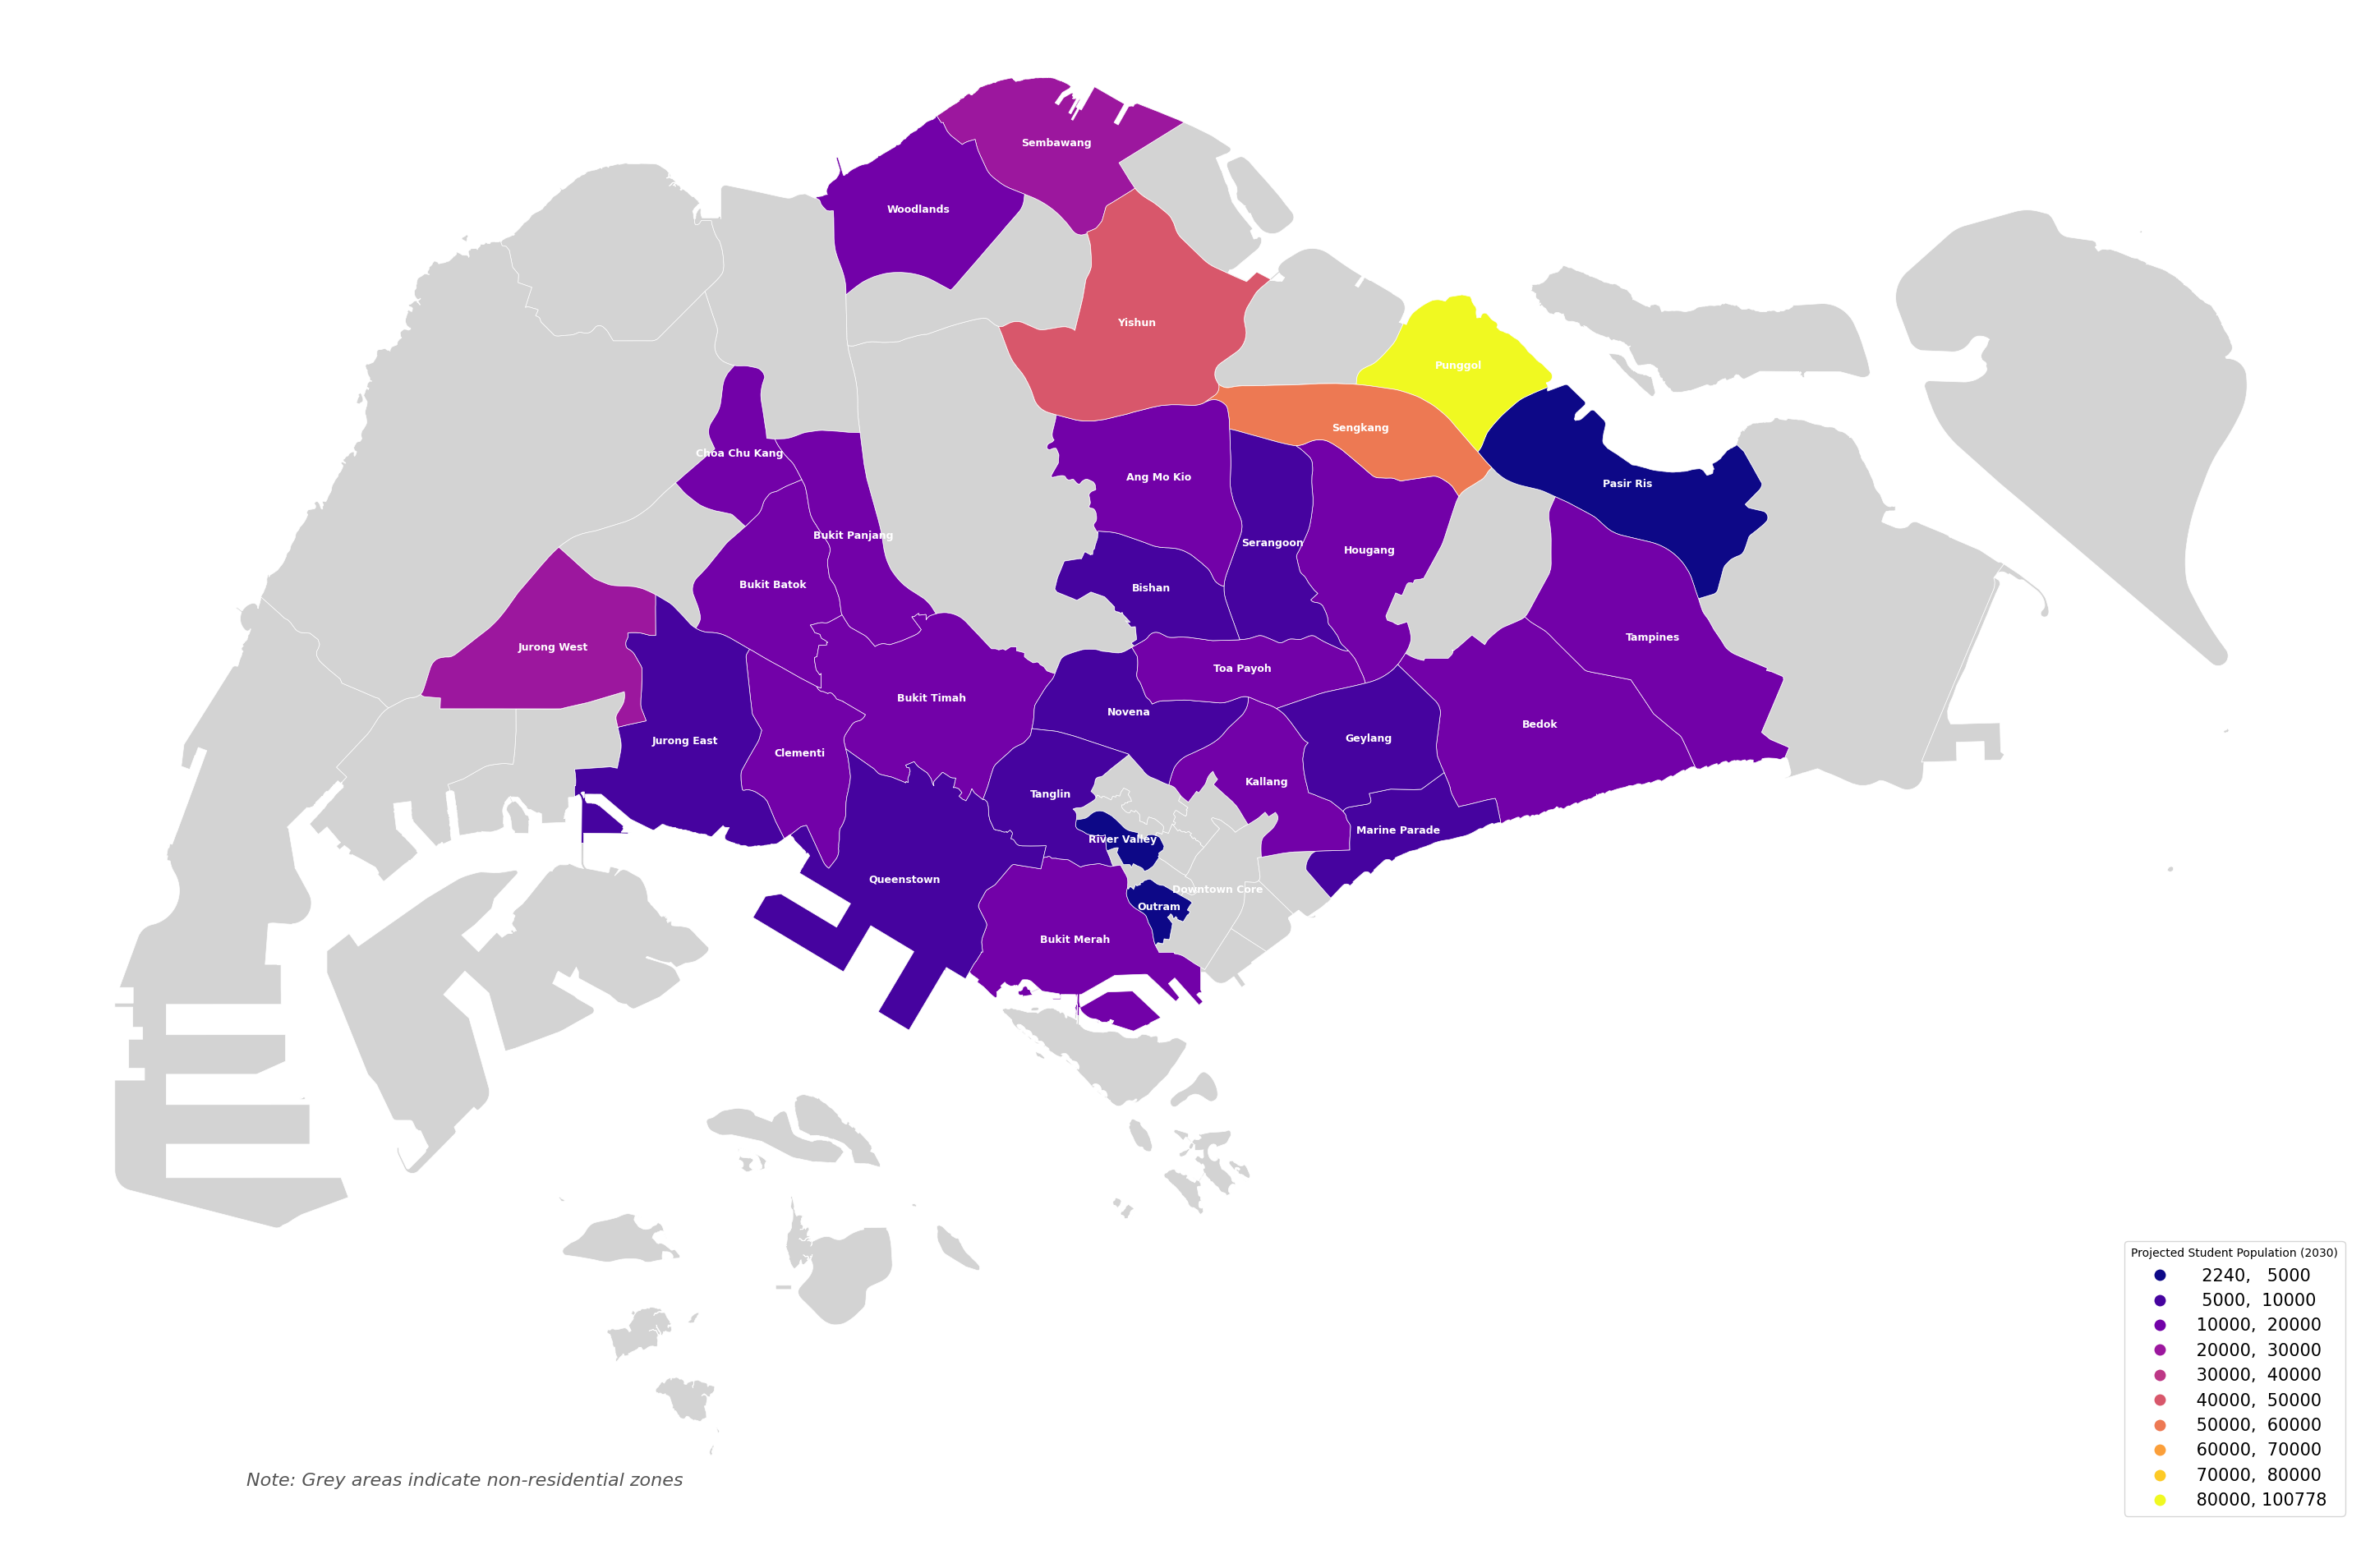

In [ ]:
gdf_student_demand = df_planning_area.merge(
    df_master,
    left_on='PLN_AREA_N',
    right_on='Planning Area',
    how='left'
)

# Colour areas that have > 0 students
data_to_plot = gdf_student_demand[gdf_student_demand['2030 Projected Students'] > 0]

fig, ax = plt.subplots(1, 1, figsize=(30, 20))

# Grey areas represent non-residential areas
df_planning_area.plot(ax=ax, color='#d3d3d3', edgecolor='white', linewidth=0.5)

# Otherwise, it represents the magnitude of individual values within a dataset using the corresponding colours
data_to_plot.plot(column='2030 Projected Students',
                  cmap='plasma',
                  scheme='UserDefined',
                  classification_kwds={'bins': [5000, 10000, 20000, 30000, 40000, 50000, 60000, 70000, 80000]},
                  legend=True,
                  ax=ax,
                  edgecolor='white',
                  linewidth=0.5,
                  legend_kwds={'title': "Projected Student Population (2030)",
                               'loc': 'lower right',
                               'fmt': "{:.0f}",
                               'fontsize': 15})


for idx, row in gdf_student_demand.iterrows():
    # 1. Check if 'Planning Area' is valid AND '2030 Projected Students' is not Null
    if pd.notna(row['Planning Area']) and pd.notna(row['2030 Projected Students']):

        # Get the center of the area
        centroid = row['geometry'].centroid

        ax.annotate(
            text=row['Planning Area'],
            xy=(centroid.x, centroid.y),
            horizontalalignment='center',
            verticalalignment='center',
            fontsize=9,          # Adjusted for better readability
            fontweight='bold',
            color='white', # Fixed: Added missing closing quote here
        )

# Comment
ax.annotate('Note: Grey areas indicate non-residential zones',
            xy=(0.1, 0.05), xycoords='figure fraction', fontsize=16, fontstyle='italic', color='#555555')

ax.axis('off')
plt.tight_layout()
plt.show()

**Interpretation:**
The bright yellow and orange areas (Punggol and Sengkang) indicate massive projected student populations, suggesting that these areas will have the highest pressure on library study spaces. The purple and magenta areas (like Bedok, Tampines, and Jurong West) show significant but "stable" student populations. These are large, mature estates that likely already have regional libraries, but may need modernizing to handle 20,000+ students. Areas like Outram and River Valley are in deep blue, indicating very low student populations. This suggests that libraries in these areas might serve a different demographic (professionals/tourists) rather than students.

**Limitations:**
- The visualization assumes that student populations are evenly distributed within a planning area. In reality, students may be clustered in specific subzones, and their needs might be better served by a library in a neighboring planning area rather than one far across their own.


## Calculating library supply-per-capita ratio per region (descriptive analysis)

**Goal:** The goal is to quantify the service pressure for each Planning Area in the year 2030, in order to identify exactly where library infrastrure may fail to meet future demand.

**Methods:** We define the Library Space Index (LSI) as follows:

$LSI = \frac{\sum \text{Library Floor Area (sqm)}_{\text{ Planning Area}}}{\text{Projected 2030 Student Population}_{\text{ Planning Area}}}$

- Numerator: Total sum of all library floor areas within the boundaries of a Planning area
- Demoninator: Projected number of resident students in year 2030 within the same Planning area

- The lower the LSI score, the greater the need for library infrastructure expansion



**Code:** The code merges supply(Libraries) and demand(Student population projection) for analysis


In [ ]:
# Aggregate total floor area per planning area
df_supply_agg = df_final_lib.groupby('PLN_AREA_N')['Floor Area (sqm)'].sum().reset_index()
df_supply_agg.rename(columns={'PLN_AREA_N': 'Planning Area'}, inplace=True)

# Merge Supply with Demand
df_lsi = pd.merge(df_master, df_supply_agg, on='Planning Area', how='left')


df_lsi['Floor Area (sqm)'] = df_lsi['Floor Area (sqm)'].fillna(0)


# Calculate LSI for each planning area
df_lsi['LSI_2030'] = df_lsi['Floor Area (sqm)'] / df_lsi['2030 Projected Students']
df_lsi['LSI_2030'] = df_lsi['LSI_2030'].fillna(0)

**Interpretation:** Based on the LSI calculation, we are able to intepret which planning areas are facing the most infrastructure strain. In particular, we are able to further categorise planning areas into sub-categories based on their readiness to serve the projected 2030 student population. This will be further discussed in the Share portion.

**Limitation:** Our constructed LSI metric is simplistic. It does not take into account several constraints:

- **Non-functional floor area:** We used floor area as a proxy for capacity. This does not take into account whether the space is actually usable for students. For example, the National Library Building has a massive total floor area (58800 sqm) but a significant portion is dedicated to heritage collections, offices and exhibition galleries. This means the actual floor area usable by a student may vary based on how a library is designed.

- **Permeability of Planning Area Boundaries:** Our analysis assumes planning areas as rigid containers. In reality, Singapore's high density transit network may make travelling to a library in an adjacent area hassle-free. We also make the assumption that students will only visit libraries in their respective residential areas. However, students visit libraries based on not just convenience but also preference and even school locations.

# Presentation of main results (Share)



> *Create a visualization, summary, infographic, or any other way you see fit to present the main findings (at least one, may be more). Structure the discussion in three parts: (1) Stakeholder: who are you presenting to in your use case; (2) visualization/summary/infographic (can be code to be executed, text, image, etc.); (3) Short narrative of final result to stakeholders.*


## Stakeholders

The results are presented to National Library Board(NLB) for future planning

## Final geo-visualization using Choropleth map

To effectively visualize the infrastructure gap, we categorize the Planning Areas into four service profiles based on their LSI scores:

Critical (LSI = 0): No existing library floor area.

High Pressure (LSI < 0.10): Very low floor area relative to student population.

Moderate (LSI 0.10 - 0.50): Average service availability.

Sufficient (LSI > 0.50): Well-equipped to handle student population.

Required info | Your answer
-------------------|------------------
GenAI tool name | Gemini 3 Flash
Input prompt | Create code for a geo-visualization using a Choropleth map using Library service Index dataframe(df_lsi) and planning area dataframe (df_planning area)
Generated output |see comment below
Impacted notebook cell | Final geo-visualisation using Chloropleth map -code cell 1

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# # 1. Prepare Data for Mapping
# gdf_lsi_map = df_planning_area.merge(
#     df_lsi,
#     left_on='PLN_AREA_N',
#     right_on='Planning Area',
#     how='left'
# )

# # Cap LSI at 1.0 for visualization so 'inf' or huge values (like Downtown Core)
# # don't crush the color scale for residential areas.
# gdf_lsi_map['LSI_Visual'] = gdf_lsi_map['LSI_2030'].clip(upper=1.0)

# # 2. Create the Map
# fig, ax = plt.subplots(1, 1, figsize=(25, 15))

# # Plot non-residential or zero-student areas in light grey
# df_planning_area.plot(ax=ax, color='#E0E0E0', edgecolor='white', linewidth=0.5)

# # Plot LSI Pressure Index
# # Use YlOrRd_r: Red = Low LSI (High Pressure), Yellow = High LSI (Low Pressure)
# gdf_lsi_map[gdf_lsi_map['2030 Projected Students'] > 0].plot(
#     column='LSI_Visual',
#     cmap='YlOrRd_r',
#     scheme='NaturalBreaks',
#     k=5,
#     legend=True,
#     ax=ax,
#     edgecolor='black',
#     linewidth=0.3,
#     legend_kwds={
#         'title': "Library Space Index (Sqm/Student)\n(Red = High Service Strain)",
#         'loc': 'lower right',
#         'fmt': "{:.2f}",
#         'fontsize': 12
#     }
# )

# # 3. Dynamic Labels for Top Priority Areas
# # Labeling areas with LSI < 0.05 (High Priority)
# for idx, row in gdf_lsi_map.iterrows():
#     if row['LSI_2030'] < 0.05 and row['2030 Projected Students'] > 0:
#         centroid = row['geometry'].centroid
#         ax.annotate(
#             text=f"{row['Planning Area']}\n(LSI: {row['LSI_2030']:.3f})",
#             xy=(centroid.x, centroid.y),
#             ha='center', va='center',
#             fontsize=10, fontweight='bold', color='black',
#             bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7)
#         )

# plt.title('2030 Library Infrastructure Gap Analysis\nDiagnostic Visualization of Service Pressure (LSI)', fontsize=22, fontweight='bold')
# plt.axis('off')
# plt.tight_layout()
# plt.show()

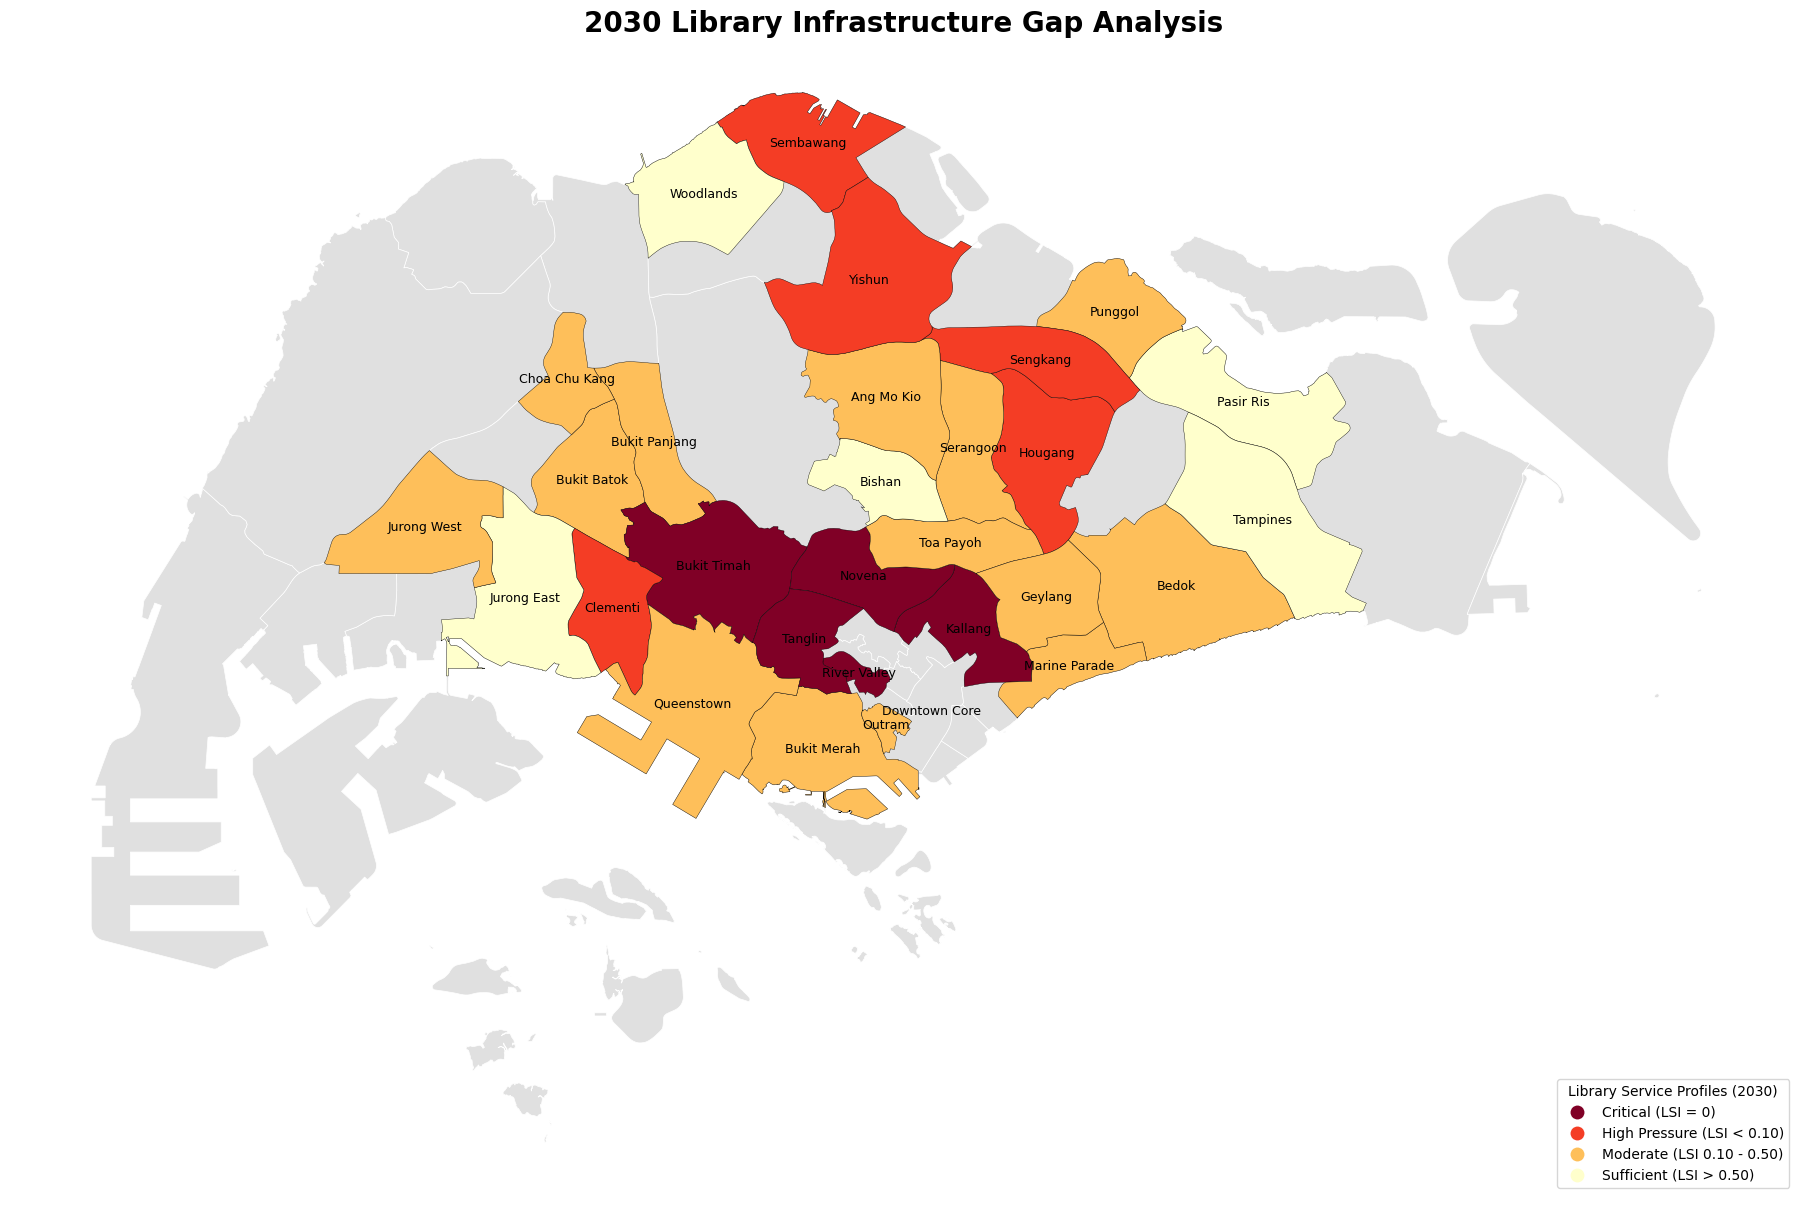

In [ ]:
# Convert lsi df to gdf for mapping
gdf_lsi_map = df_planning_area.merge(
    df_lsi,
    left_on='PLN_AREA_N',
    right_on='Planning Area',
    how='left'
)

fig, ax = plt.subplots(1, 1, figsize=(25, 15))

# Plot non-residential areas in light grey
df_planning_area.plot(ax=ax, color='#E0E0E0', edgecolor='white', linewidth=0.5)

# Plot LSI Pressure Index
gdf_lsi_map[gdf_lsi_map['2030 Projected Students'] > 0].plot(
                  column='LSI_2030',
                  ax=ax,
                  cmap='YlOrRd_r',
                  scheme='UserDefined',
                  classification_kwds={'bins': [0.001, 0.10, 0.50]},
                  legend=True,
                  edgecolor='black',
                  linewidth=0.3,
                  legend_kwds={
                      'title': "Library Service Profiles (2030)",
                      'loc': 'lower right',
                      'labels': [
                          'Critical (LSI = 0)',
                          'High Pressure (LSI < 0.10)',
                          'Moderate (LSI 0.10 - 0.50)',
                          'Sufficient (LSI > 0.50)'
                      ]
                  })

for idx, row in gdf_lsi_map.iterrows():
    if pd.notna(row['Planning Area']) and pd.notna(row['2030 Projected Students']):
        centroid = row['geometry'].centroid
        ax.annotate(
            text=row['Planning Area'],
            xy=(centroid.x, centroid.y),
            ha='center', va='center',
            fontsize=9,
            color='black')

plt.title('2030 Library Infrastructure Gap Analysis', fontsize=20, fontweight='bold')
plt.axis('off')
plt.show()

**Narrative:**


The Choropleth map delineates Singapore into four distinct zones based on the projected 2030 student demand.

1. Critical Zones (Deep Red): A major infrastructure gap is identified within the Central Region, specifically in Bukit Timah, Tanglin, Novena, River Valley and Kallang.  Despite these areas having significant student populations, there is a complete lack of designated library floor area within the planning boundary.

2. High Pressure Zones (Orange-Red): Heavy strain is seen in large residential areas such as Sengkang, Yishun, and Hougang. Although libraries exist here, available floor area per projected capita is critically low.

3. Moderate Zones (Orange): Areas like Bedok, Tampines, and Jurong West fall into the moderate category. These areas have established infrastructure that provides a reasonable library capacity for their respective student populations.

4. Sufficient Zones (Pale Yellow): Areas like Jurong East, Woodlands, and Tampines are considered to have sufficient library service capacity for their respective student populations.

# Possible actions based on results (Act)

Based on our 2030 analysis, we recommend the following actions for the National Library Board (NLB) in ensuring students across Singapore have equal access to library resources.

1. Develop new physical library infrastructure within the planning boundaries of identified **Critical Zones**, namely in Bukit Timah, Tanglin, Novena, River Valley and Kallang.

2. Consider expansion of existing libraries within **High Pressure Zones**, namely in Clementi, Hougang, Sengkang, Sembawang and Yishun.

# Final Reflection

## Considerations on data ethics

We didn't keep track of metadata giving credit/ showing attribution to the different sources and dataset authors. If we publish the derived dataset or notebook, we would have to provide proper attribution and ensure data usage is compliant with licences.

## Considerations on data privacy and security

As our study is solely based on open data without any personal information, there are no special risks or measures to be taken to ensure data privacy or security.